# 03b — 3-engine OCR fusion (Paddle × Qwen-VL × DeepSeek) + post-OCR language detection

**Phase 3d + 3e** (plan §6 Stage 3). Runs after `03_dual_extraction.ipynb` (Paddle + DeepSeek)
and after `scripts/run_qwen_ocr.py` (Qwen-VL-OCR third engine).

## Engines and their roles

| Engine | Role | Source | Quality notes |
|--------|------|--------|---------------|
| **PaddleOCR** (PP-OCRv5) | **Alignment anchor + safety fallback** | local, offline | Real per-line confidence (mean 0.905); 0.28 % length-outlier rate; always trusted when it returns text |
| **Qwen-VL-OCR** (`qwen-vl-ocr-latest`) | **Primary LLM — character correction source** | Silra API | 0.25 % length-outlier rate; 99.7 % corpus coverage; cleanest LLM distribution; **wins by default** when quality gate passes |
| **DeepSeek-OCR** | **Secondary verification only** | Silra API | 32.67 % length-outlier rate; 380 / 2 071 pages of hallucinated markdown; used only when Qwen is excluded |

> ⚠ **Silra confidence constants are hardcoded and unusable** — DeepSeek always returns 0.85,
> Qwen always returns 0.82, zero variance across all pages.  These constants are **ignored** by
> the fusion gate.  See AGENTS.md §11 (2026-05-20 entry) for the corpus-audit evidence.

## Fusion algorithm (`apps.backend.ocr.fusion.fuse_results`)

1. **Quality gate** (replaces the retired confidence threshold):
   - `char_count ≤ 3 × paddle_chars` — blocks DeepSeek's length-outlier hallucinations
   - `cjk_ratio ≥ 0.40` — blocks Latin-dominated or empty outputs
   - `noise_index ≤ 0.30` — blocks markdown-header / pipe-table contamination
   - Thresholds are corpus-tuned from the 2 942-page audit (`logs/ocr_audit_report.json`)
2. **Best-LLM selection** (priority order, NOT confidence):
   - **Qwen wins by default** when both pass the gate.
   - DeepSeek wins only when Qwen is excluded.
3. **2-way alignment**: `difflib.SequenceMatcher` aligns Paddle (`a`) vs best-LLM (`b`).
   - `equal` → both agree; per-char confidence 1.0
   - `replace` → **LLM wins** (rare-glyph correction is its job); confidence 0.7
   - `insert` → LLM adds chars Paddle missed; confidence 0.7
   - `delete` → Paddle's extra chars kept; confidence 0.7
4. **Single-engine fallback**: if all LLMs fail the gate → Paddle only.
5. **`fusionAgreementRate`** = chars in `equal` spans / total fused chars (unchanged; used
   as the uncertainty signal for Phase 4 / 5 active-learning prioritisation).

**Outputs**: `textFused`, `fusionAgreementRate`, `fusionSingleEngine`, `fusionWinnerLlm`,
`fusionStatus`, and authoritative `language` / `scriptMix` / `kuntenMarks`.

**Next**: Phase 4 — `04_layout_analysis.ipynb`

In [1]:
from __future__ import annotations

import json
import logging
import os
import sys
from datetime import datetime, timezone
from pathlib import Path

from dotenv import load_dotenv

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'pyproject.toml').exists(), f'cannot locate repo root from {Path.cwd()}'
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

loaded = load_dotenv(REPO_ROOT / '.env')
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s: %(message)s')
logging.getLogger('neo4j.notifications').setLevel(logging.WARNING)
logging.getLogger('apps.backend.pipeline.fusion').setLevel(logging.INFO)

ARTIFACT_DIR = REPO_ROOT / 'notebooks' / '_artifacts' / '03b_fusion'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PRIOR = REPO_ROOT / 'notebooks' / '_artifacts' / '03_dual_extraction' / 'extraction.json'

RUN_FULL = os.getenv('RUN_FULL', '0') == '1'
MAX_PAGES = int(os.getenv('MAX_PAGES', '0' if RUN_FULL else '30'))
MAX_PAGES = None if RUN_FULL else MAX_PAGES
RECOMPUTE = os.getenv('RECOMPUTE', '0') == '1'
DOCUMENT_ID = os.getenv('DOCUMENT_ID') or None
RUN_LANG_DETECT = os.getenv('RUN_LANG_DETECT', '1') == '1'

print(f'repo root      : {REPO_ROOT}')
print(f'.env loaded    : {loaded}')
print(f'artifact dir   : {ARTIFACT_DIR}')
print(f'RUN_FULL       : {RUN_FULL}  (MAX_PAGES={MAX_PAGES})')
print(f'RECOMPUTE      : {RECOMPUTE}')
print(f'DOCUMENT_ID    : {DOCUMENT_ID!r}')
print(f'RUN_LANG_DETECT: {RUN_LANG_DETECT}')

repo root      : /Users/mohasani/Ancient
.env loaded    : True
artifact dir   : /Users/mohasani/Ancient/notebooks/_artifacts/03b_fusion
RUN_FULL       : False  (MAX_PAGES=30)
RECOMPUTE      : False
DOCUMENT_ID    : None
RUN_LANG_DETECT: True


In [2]:
if not PRIOR.exists():
    raise RuntimeError(
        f'Missing prior artifact: {PRIOR}. Run 03_dual_extraction.ipynb first.'
    )
prior_data = json.loads(PRIOR.read_text())
print('Phase 3 status (from prior artifact):')
print(f'  corpus_totals: {prior_data.get("corpus_totals")}')
print(f'  by_engine_status: {json.dumps(prior_data.get("extraction_summary", {}).get("by_engine_status"), ensure_ascii=False)}')

Phase 3 status (from prior artifact):
  corpus_totals: {'total_body': 2942, 'preprocessed': 2313, 'paddle_ok': 2291, 'deepseek_ok': 386}
  by_engine_status: {"paddleocr": {"empty": 22, "ok": 2291}, "deepseek_ocr": {"(unset)": 1502, "ok": 386, "empty": 12, "failed": 413}}


In [3]:
from apps.backend.graph.neo4j_client import get_driver

driver = get_driver()

with driver.session() as session:
    eligible = session.run('''
        MATCH (p:PAGE)
        WHERE p.mode = 'ocr' AND (p.role IS NULL OR p.role = 'body')
          AND (
              p.paddleOcrStatus = 'ok'
           OR p.deepseekOcrStatus = 'ok'
           OR p.qwenVlOcrStatus = 'ok'
          )
        RETURN
          count(p) AS total_fusable,
          count(CASE WHEN p.paddleOcrStatus='ok' THEN 1 END) AS paddle_ok,
          count(CASE WHEN p.qwenVlOcrStatus='ok' THEN 1 END) AS qwen_ok,
          count(CASE WHEN p.deepseekOcrStatus='ok' THEN 1 END) AS deepseek_ok,
          count(CASE WHEN p.paddleOcrStatus='ok' AND p.qwenVlOcrStatus='ok' THEN 1 END) AS paddle_qwen_ok,
          count(CASE WHEN p.paddleOcrStatus='ok' AND p.deepseekOcrStatus='ok' AND p.qwenVlOcrStatus='ok' THEN 1 END) AS all_three_ok,
          count(CASE WHEN p.paddleOcrStatus='ok' AND p.qwenVlOcrStatus<>'ok' AND p.deepseekOcrStatus<>'ok' THEN 1 END) AS paddle_only,
          count(CASE WHEN p.fusionStatus IS NOT NULL THEN 1 END) AS already_fused
    ''').single()

print('Eligible pages for fusion:')
for k, v in dict(eligible).items():
    print(f'  {k:>18}: {v}')

Eligible pages for fusion:
       total_fusable: 2900
           paddle_ok: 2874
             qwen_ok: 2406
         deepseek_ok: 2223
      paddle_qwen_ok: 2394
        all_three_ok: 1906
         paddle_only: 180
       already_fused: 0


## 1. Sanity-check the fusion logic

Run `fuse_results` on a hand-crafted pair of strings so the per-segment
alignment is auditable before we let it loose on the corpus.

In [4]:
from apps.backend.ocr.base import OCRPageResult
from apps.backend.ocr.fusion import fuse_results

# ─── Baseline results ────────────────────────────────────────────────────────
# Paddle has real confidence; DeepSeek/Qwen have Silra's hardcoded constants.
# 疏議 vs 疏義: classical variant — the LLM should win the replace opcode.
paddle = OCRPageResult(
    engine='paddleocr', model_version='PP-OCRv5-mobile/ch', page_id='test::p001',
    text='唐律疏議卷一名例\n諸謀反者皆斬',
    confidence=0.905, char_count=14,
)
deepseek = OCRPageResult(
    engine='deepseek_ocr', model_version='deepseek-ocr', page_id='test::p001',
    text='唐律疏義卷一名例\n諸謀反者皆斬之',
    confidence=0.85,   # hardcoded constant — NOT a quality signal
    char_count=15,
)
qwen = OCRPageResult(
    engine='qwen_vl_ocr', model_version='qwen-vl-ocr-latest', page_id='test::p001',
    text='唐律疏議卷一名例\n諸謀反者皆斬之',
    confidence=0.82,   # hardcoded constant — NOT a quality signal
    char_count=15,
)

# --- Test 1: 3-way fusion — Qwen wins by default (priority, not confidence) ---
f3 = fuse_results(paddle, deepseek, qwen)
print('=== Test 1: normal 3-way fusion ===')
print('fused text   :', repr(f3.text_fused))
print('agreement    :', f3.agreement_rate)
print('winner LLM   :', f3.winner_llm)    # must be "qwen_vl_ocr" (priority order)
print('single engine:', f3.single_engine)

# Verify the replace opcode went to the LLM, not Paddle.
replace_segs = [s for s in f3.segments if s.op == 'replace']
for seg in replace_segs:
    print(f'  replace: {repr(seg.text)!s:30} source={seg.source}  '
          f'(LLM wins = {seg.source != "paddleocr"})')
assert all(s.source != 'paddleocr' for s in replace_segs), \
    'LLM should win all replace opcodes'
assert f3.winner_llm == 'qwen_vl_ocr', f'Expected Qwen to win, got {f3.winner_llm!r}'
print('✓  Qwen wins (priority order)  ✓  LLM wins replace opcodes')
print()

# --- Test 2: Paddle fallback via quality gate — char-count outlier excluded ---
# DeepSeek-style hallucination: char_count >> 3 × paddle (3 × 14 = 42).
bloated_ds = OCRPageResult(engine='deepseek_ocr', model_version='deepseek-ocr',
    page_id='test::p001',
    text='## 唐律疏議\n' * 20,  # 240 chars — 17 × paddle chars → excluded
    confidence=0.85, char_count=240)
bloated_qw = OCRPageResult(engine='qwen_vl_ocr', model_version='qwen-vl-ocr-latest',
    page_id='test::p001',
    text='## 唐律\n' * 20,      # 160 chars — also excluded
    confidence=0.82, char_count=160)
f_fallback = fuse_results(paddle, bloated_ds, bloated_qw)
print('=== Test 2: Paddle fallback (both LLMs fail char-count gate) ===')
print('single engine:', f_fallback.single_engine)   # must be "paddleocr"
print('winner LLM   :', f_fallback.winner_llm)      # must be None
print('fused text   :', repr(f_fallback.text_fused))
assert f_fallback.single_engine == 'paddleocr', 'Expected Paddle fallback'
print('✓  Paddle fallback triggered')
print()

# --- Test 3: Qwen excluded → DeepSeek used as secondary ---
low_cjk_qwen = OCRPageResult(engine='qwen_vl_ocr', model_version='qwen-vl-ocr-latest',
    page_id='test::p001',
    text='Column1 Column2 Column3 Column4 Column5 latin text only',  # cjk_ratio ≈ 0
    confidence=0.82, char_count=50)
f_ds_fallback = fuse_results(paddle, deepseek, low_cjk_qwen)
print('=== Test 3: Qwen excluded (low CJK ratio) → DeepSeek as secondary ===')
print('winner LLM   :', f_ds_fallback.winner_llm)   # must be "deepseek_ocr"
print('single engine:', f_ds_fallback.single_engine)
assert f_ds_fallback.winner_llm == 'deepseek_ocr', 'Expected DeepSeek when Qwen excluded'
print('✓  DeepSeek used as secondary when Qwen excluded')


=== Test 1: normal 3-way fusion ===
fused text   : '唐律疏議卷一名例\n諸謀反者皆斬之'
agreement    : 0.9375
winner LLM   : qwen_vl_ocr
single engine: None
✓  Qwen wins (priority order)  ✓  LLM wins replace opcodes

=== Test 2: Paddle fallback (both LLMs fail char-count gate) ===
single engine: paddleocr
winner LLM   : None
fused text   : '唐律疏議卷一名例\n諸謀反者皆斬'
✓  Paddle fallback triggered

=== Test 3: Qwen excluded (low CJK ratio) → DeepSeek as secondary ===
winner LLM   : deepseek_ocr
single engine: None
✓  DeepSeek used as secondary when Qwen excluded


## 2. Pre-fusion HITL calibration (small sample)

Before committing to the full corpus run, this section inspects a stratified
sample of **multi-engine pages** (pages where Paddle + at least one LLM succeeded)
to let you validate the new quality-signal-gated fusion algorithm.

All trial fusions in this section are computed **in-memory — nothing is written
to Neo4j**. The 4-panel display shows:

- the preprocessed page image
- PaddleOCR raw text (alignment anchor)
- Qwen-VL-OCR raw text (primary LLM — wins by default)
- DeepSeek-OCR raw text (secondary — used only if Qwen fails quality gate)
- the algorithm's `replace` opcode choices (should be the LLM, not Paddle)

After reviewing, edit `human_prefs` in the following cell to record your
preference per page (`'paddleocr'` | `'qwen_vl_ocr'` | `'deepseek_ocr'` | `'agree'`),
then run the calibration report cell. The report saves a `hitl_calibration.json`
audit log to `notebooks/_artifacts/03b_fusion/`.

**To bypass this gate** (CI / unattended runs): set env var `SKIP_HITL=1`
or flip `SKIP_HITL = True` in the code cell below before running.

MinIO connected  (bucket=ancient-pages)
Pages available (Paddle + ≥1 LLM): 60
Sample size                        : 15  (5 low / 5 mid / 5 high agreement)
Rendering 4-panel display …


Paddle span (anchor),LLM span (correction),Algorithm picks
.,2,qwen_vl_ocr ✓ LLM
Paddle span (anchor),LLM span (correction),Algorithm picks
’,·,qwen_vl_ocr ✓ LLM
残,殘,qwen_vl_ocr ✓ LLM
令,此卷本世紀初出於敦煌，為伯希和掠走，現藏法國巴黎國立圖書館，編號P.2819。卷子首,qwen_vl_ocr ✓ LLM
年用,尾皆缺，共存六紙，一百零四行，每整行字數約爲十六——二十。紙縫背各鈔有一方「涼州都,qwen_vl_ocr ✓ LLM
主事姓名,督府印」。卷背所抄為東卓子集。,qwen_vl_ocr ✓ LLM
录,逐録,qwen_vl_ocr ✓ LLM
纸縫背各鈴有,其長官署位准尚 右尚書省與諸臺省相移式。內外諸司 某司郎中具官封。 都省則左右司令史姓名 郎中,qwen_vl_ocr ✓ LLM
方7凉州都,人署。,qwen_vl_ocr ✓ LLM

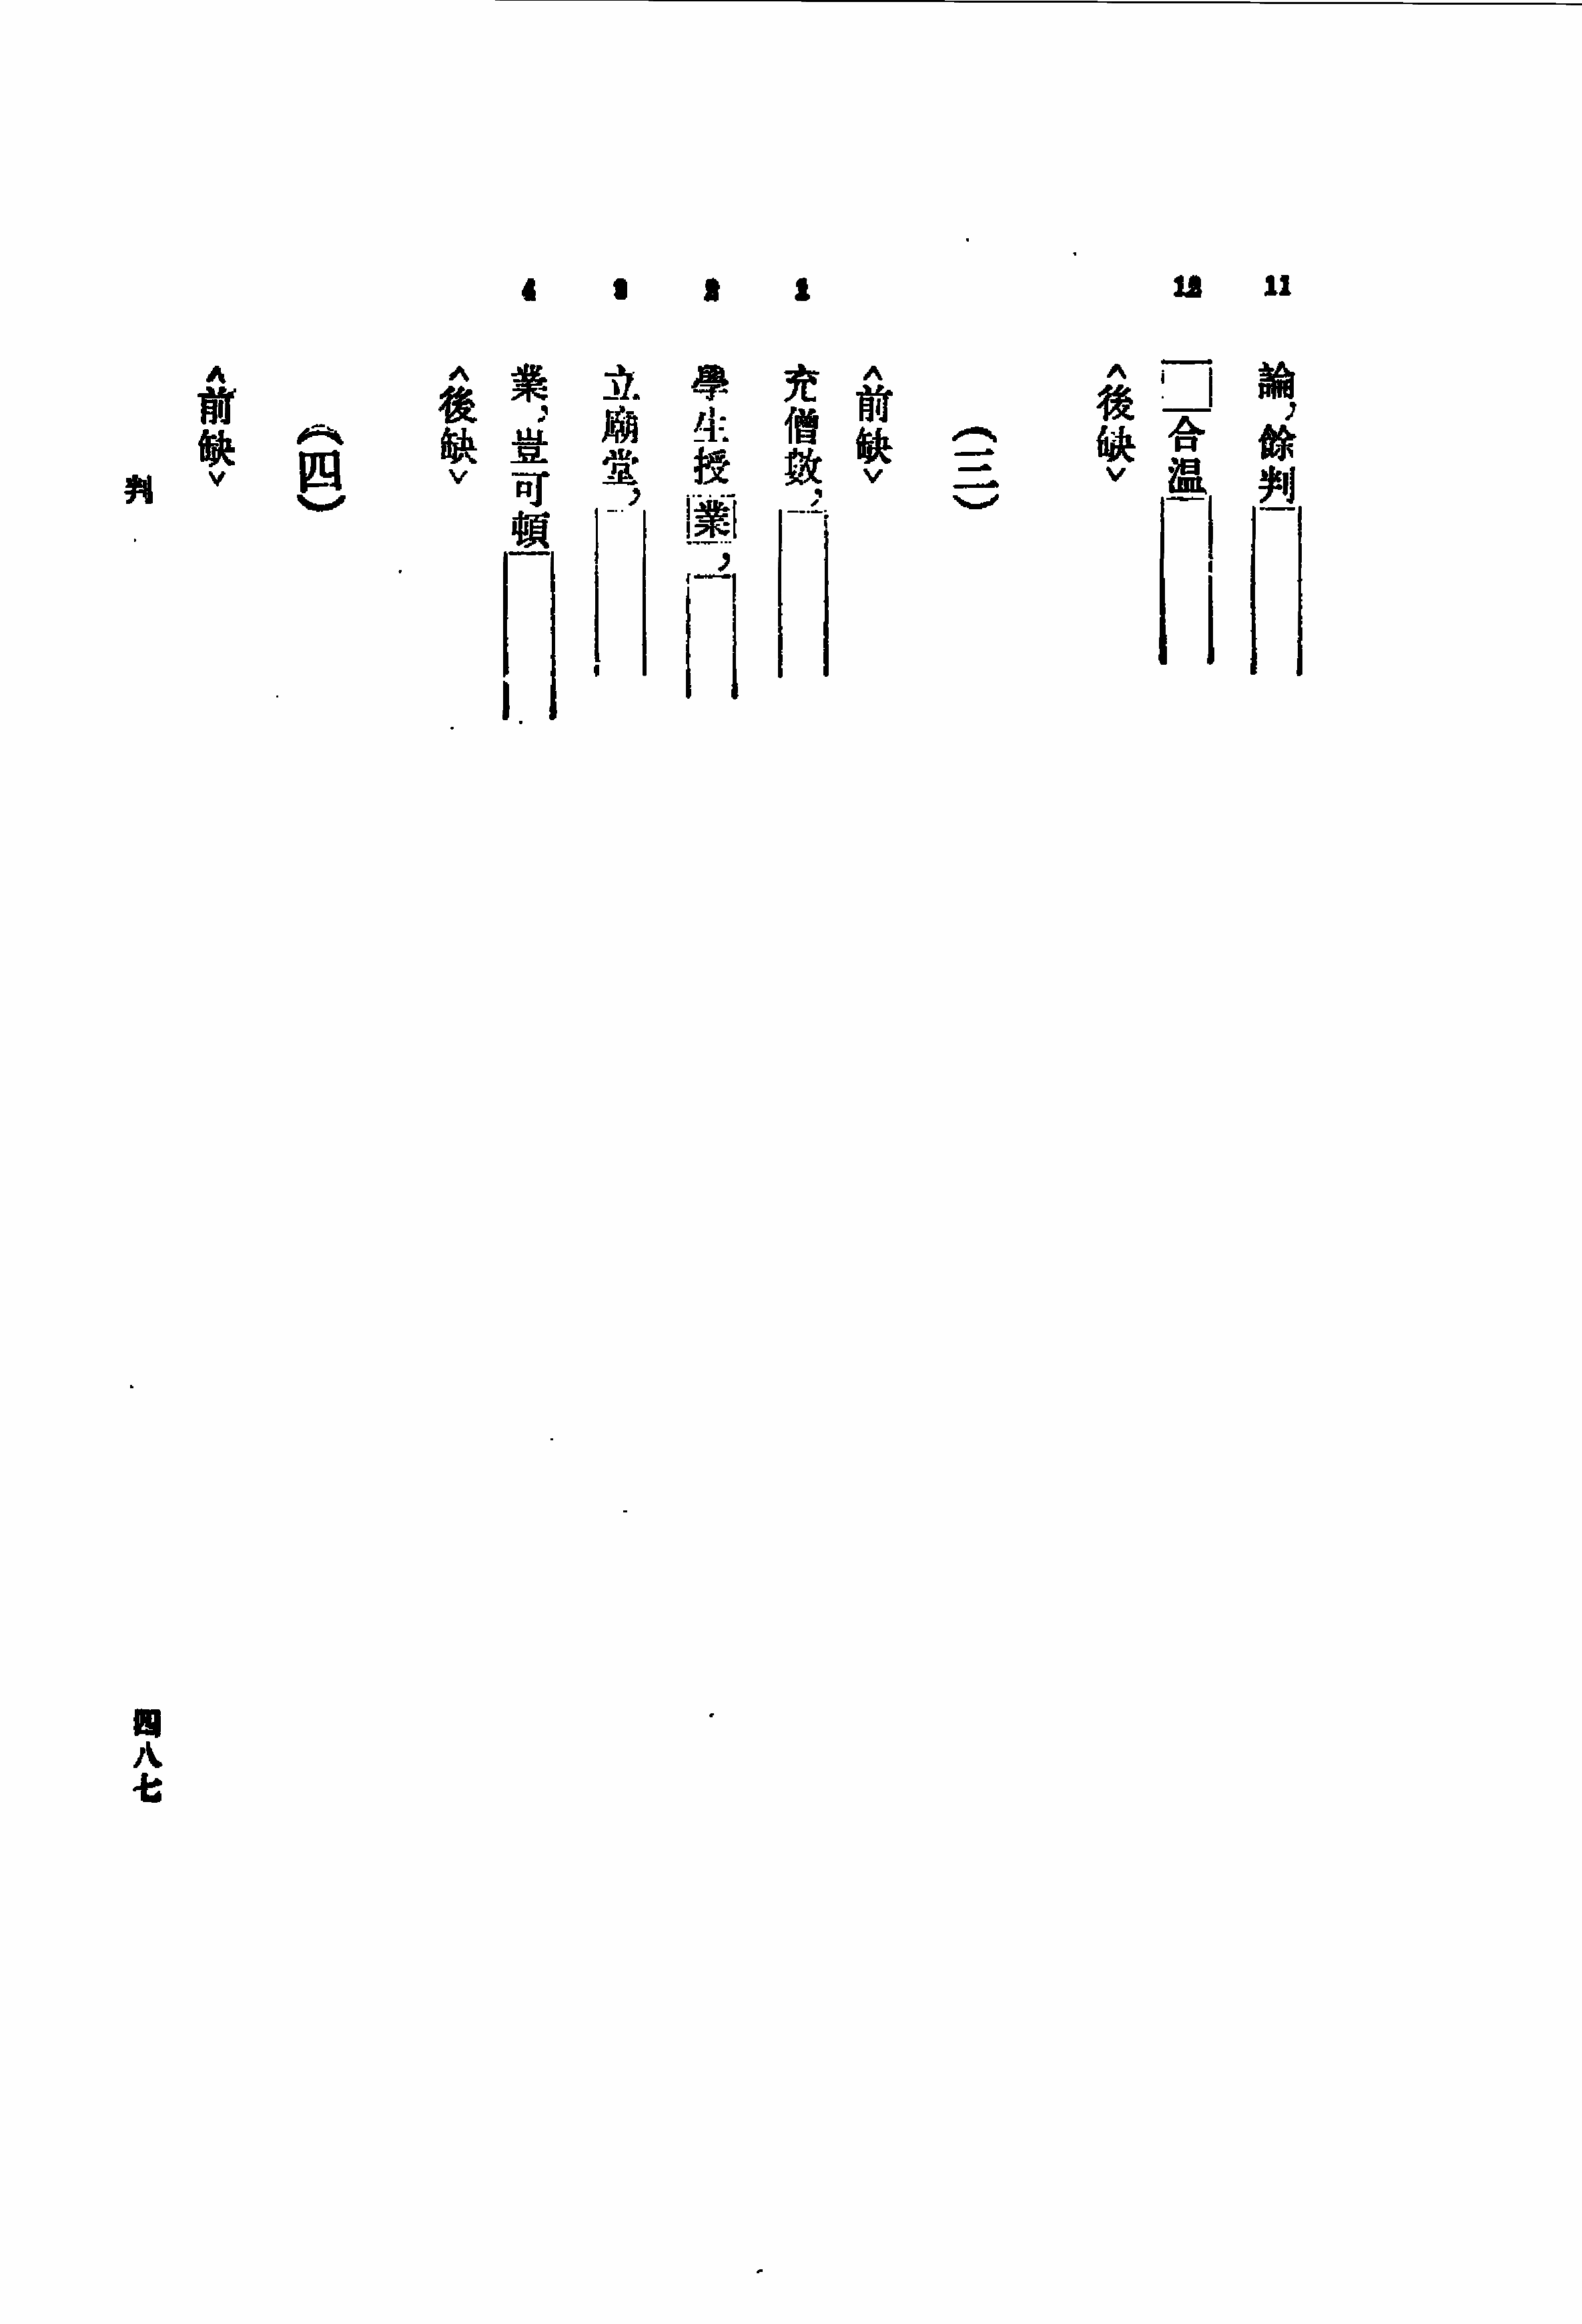
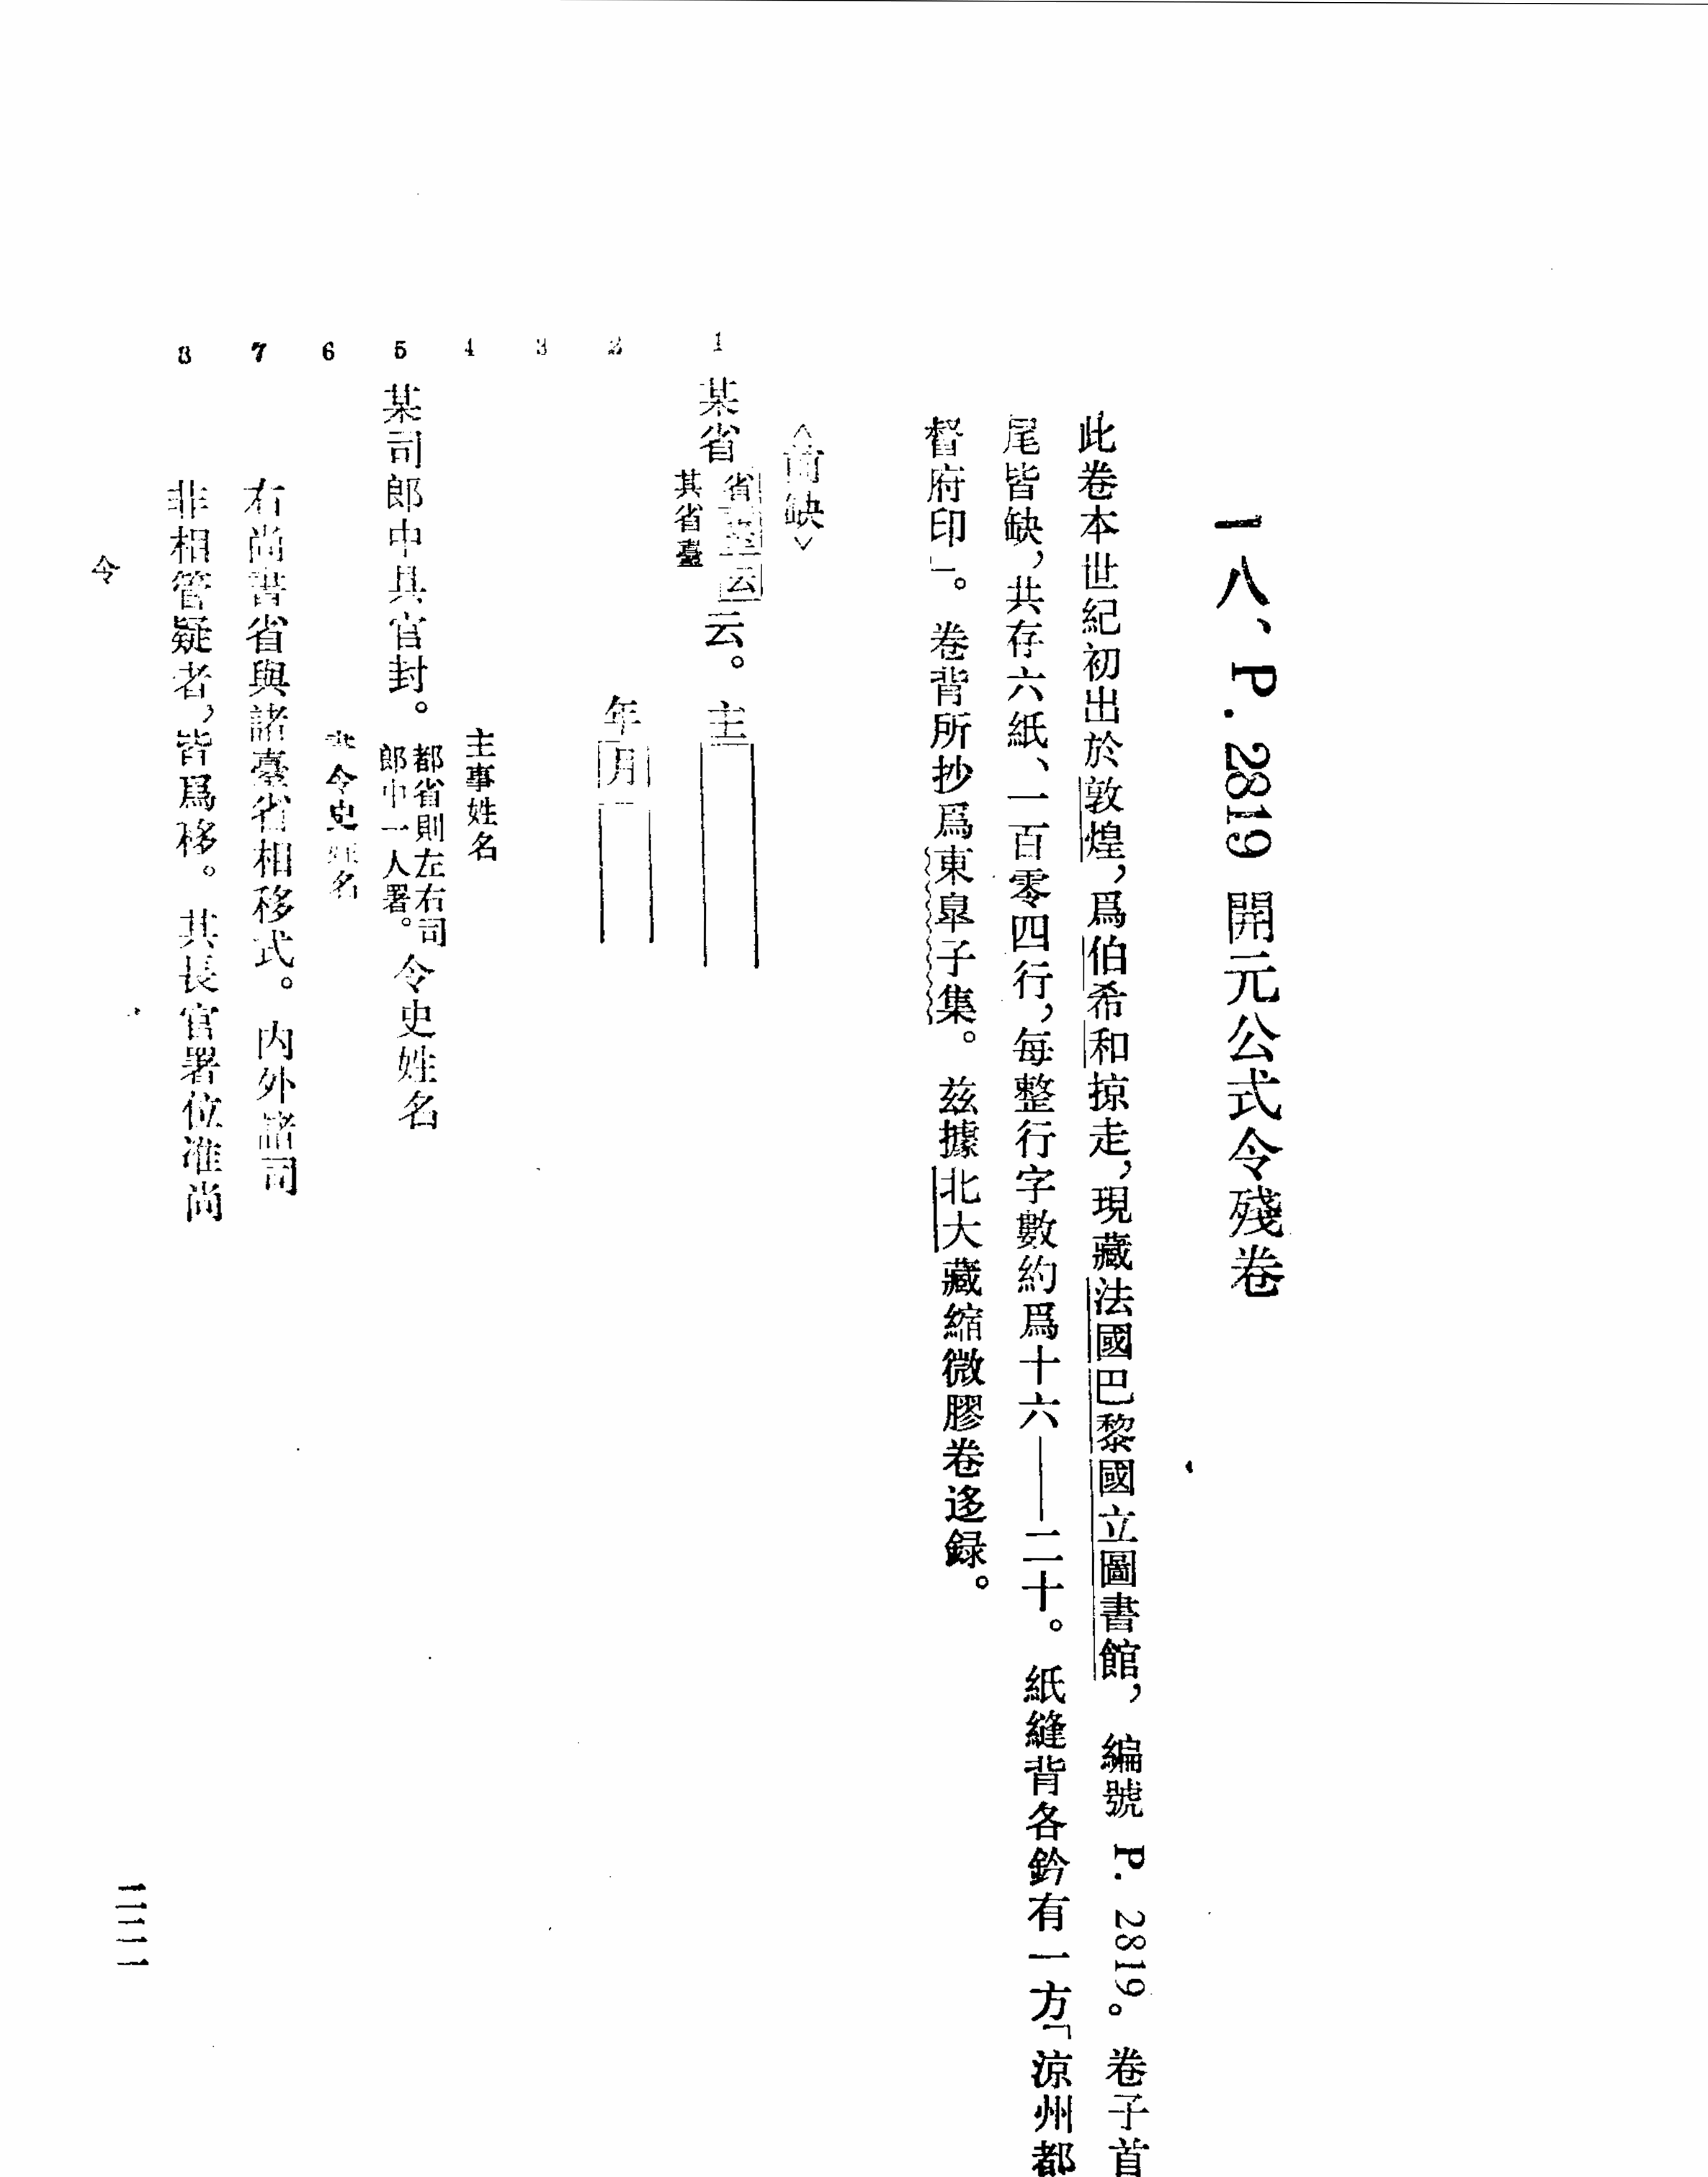
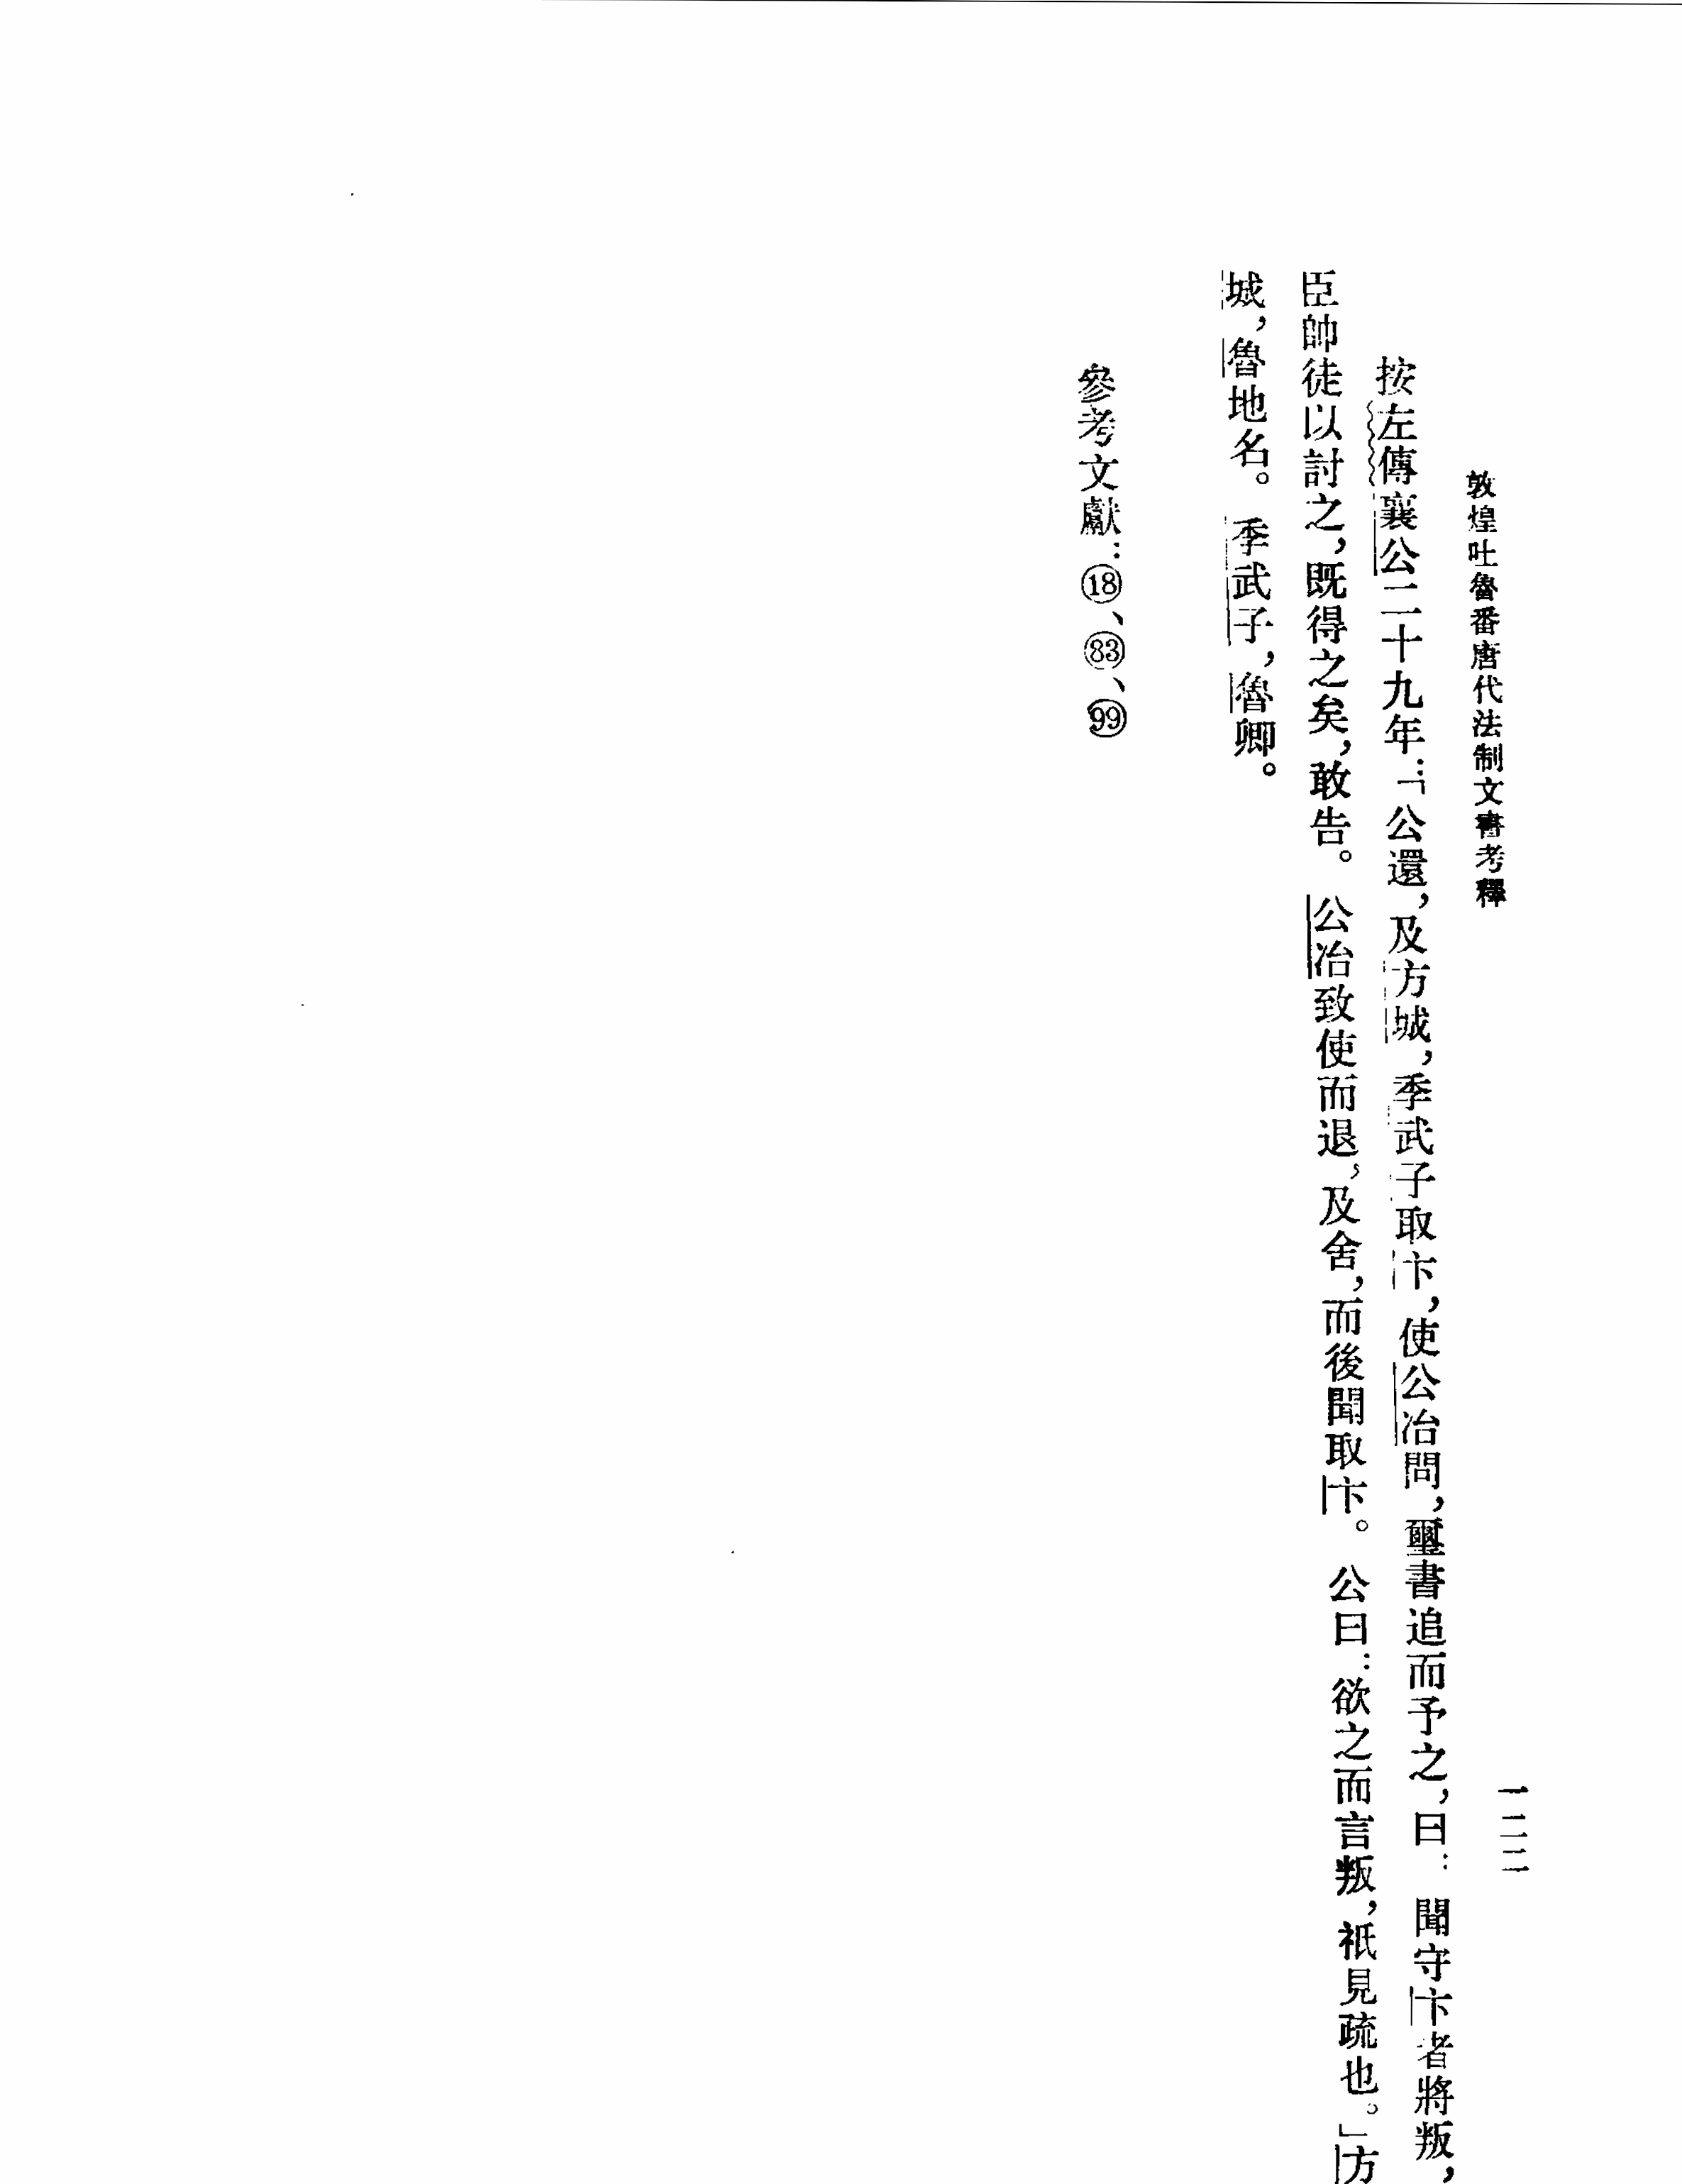
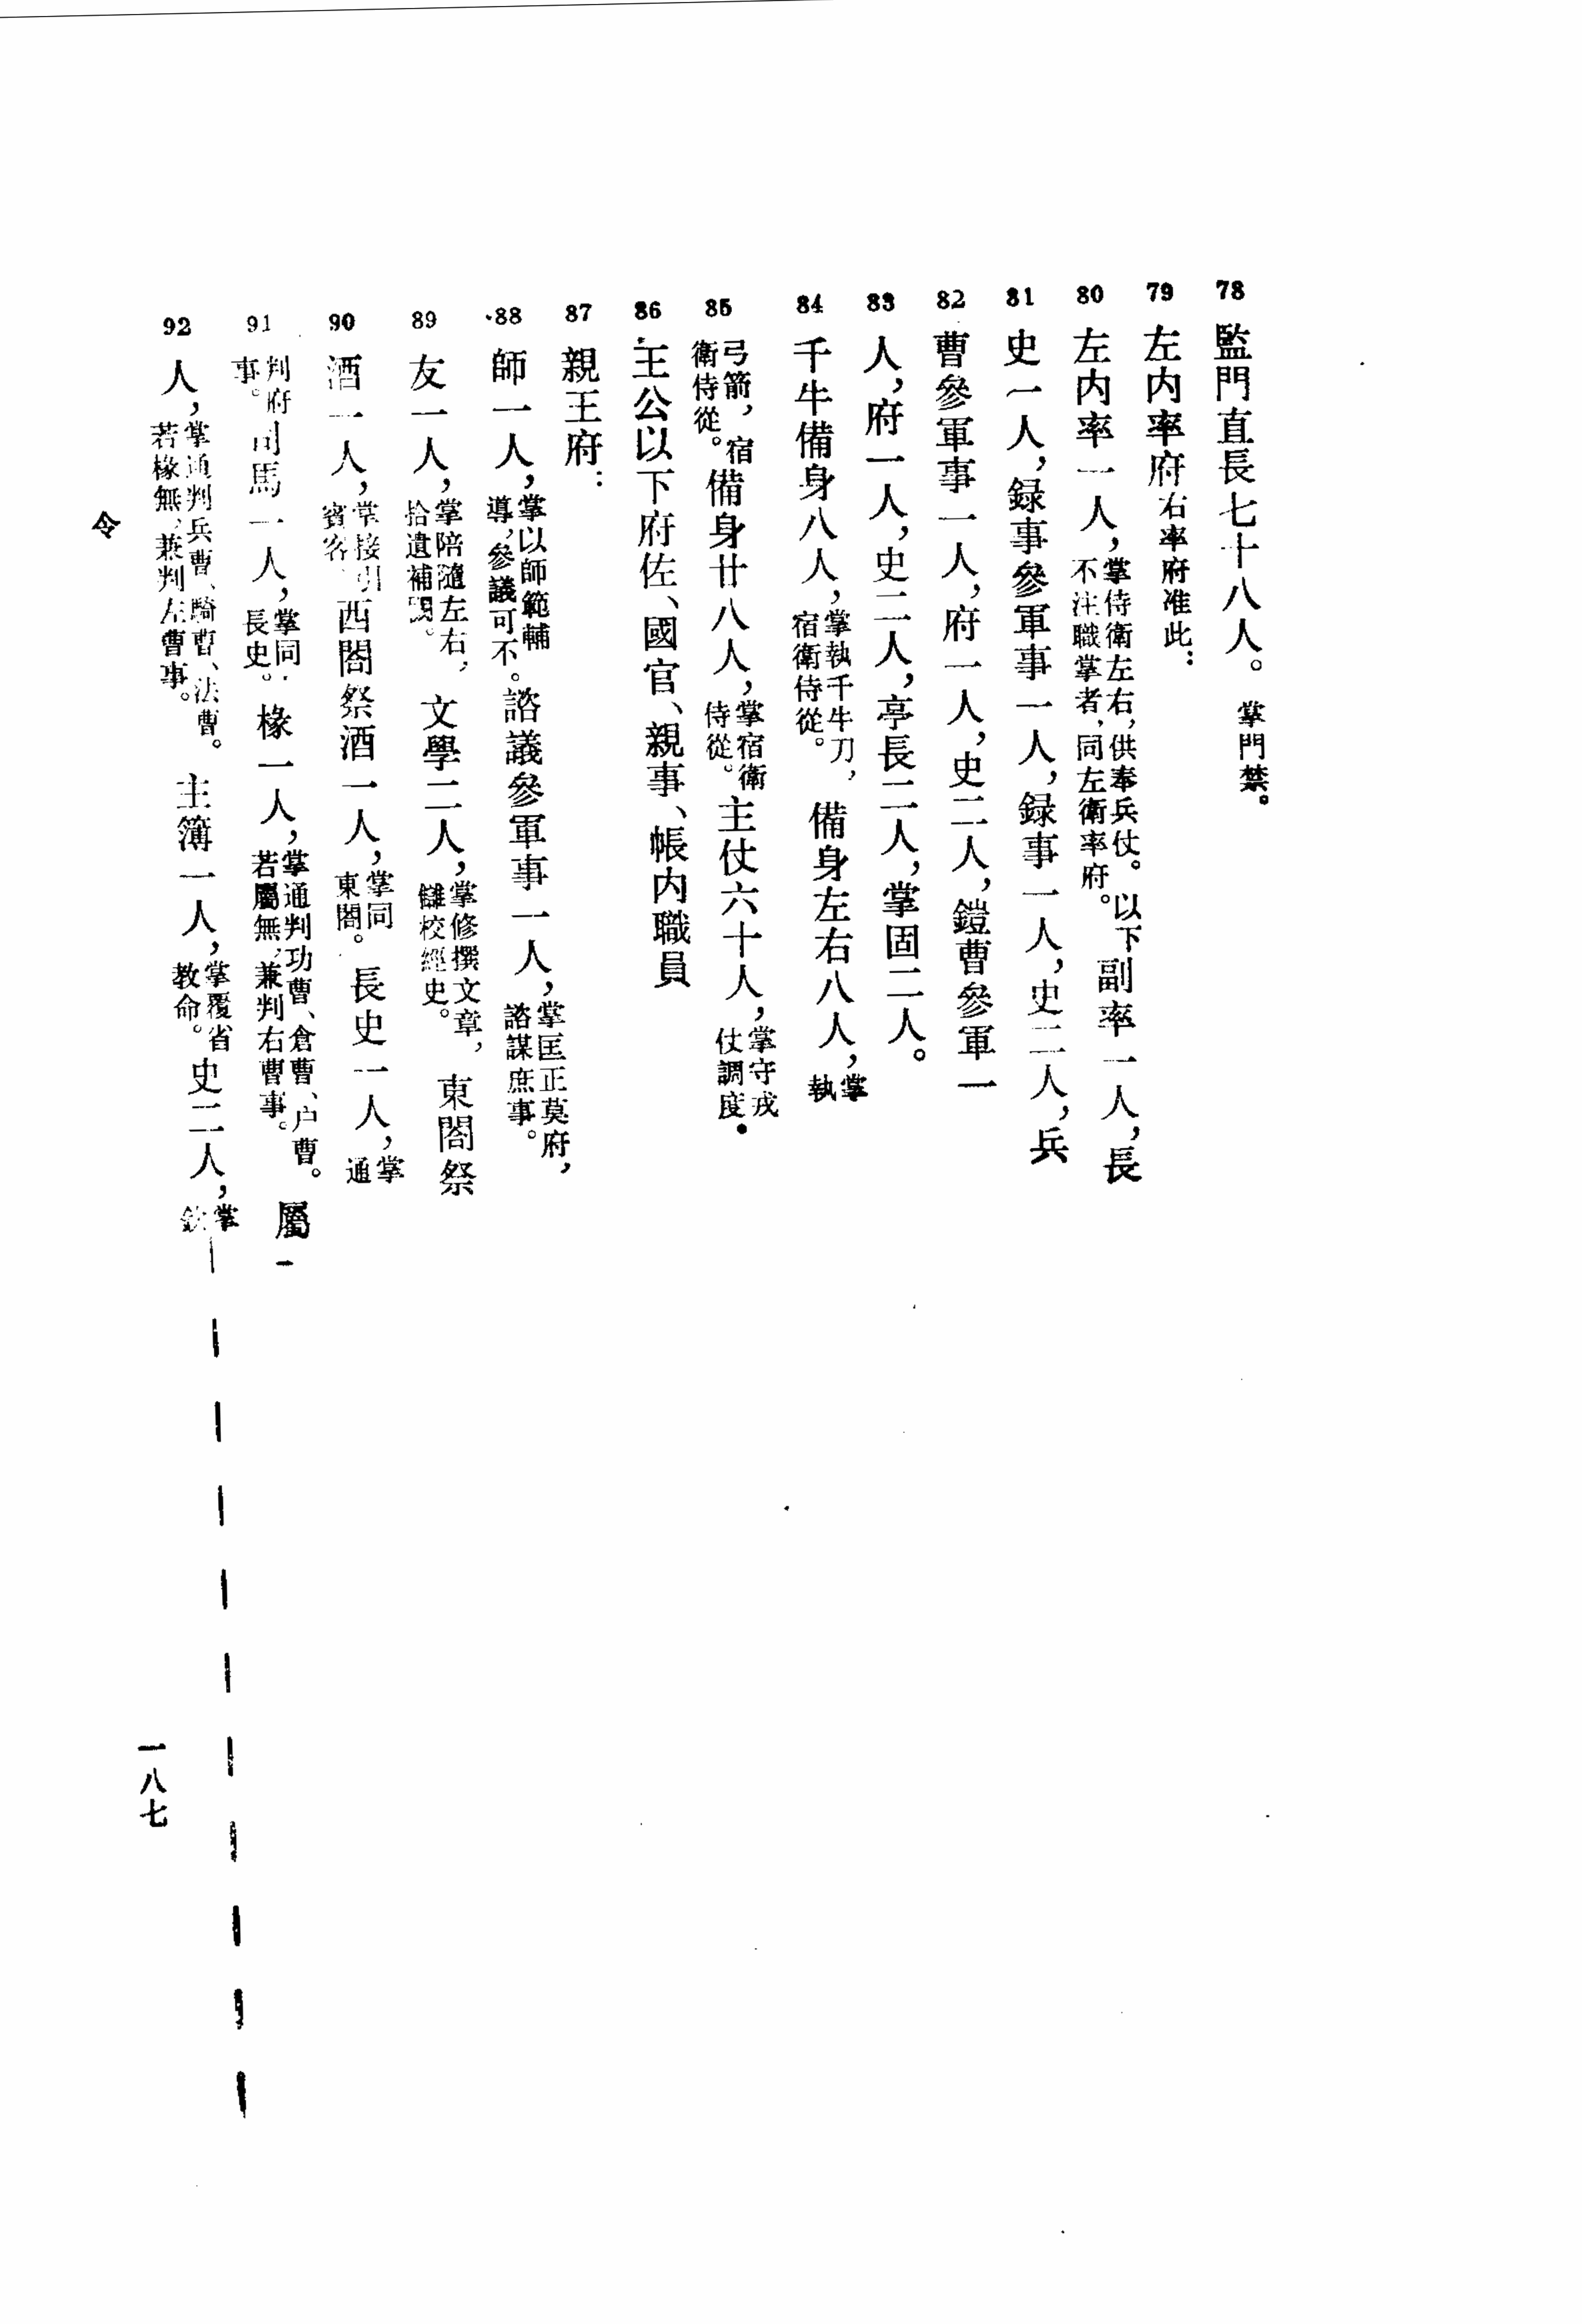
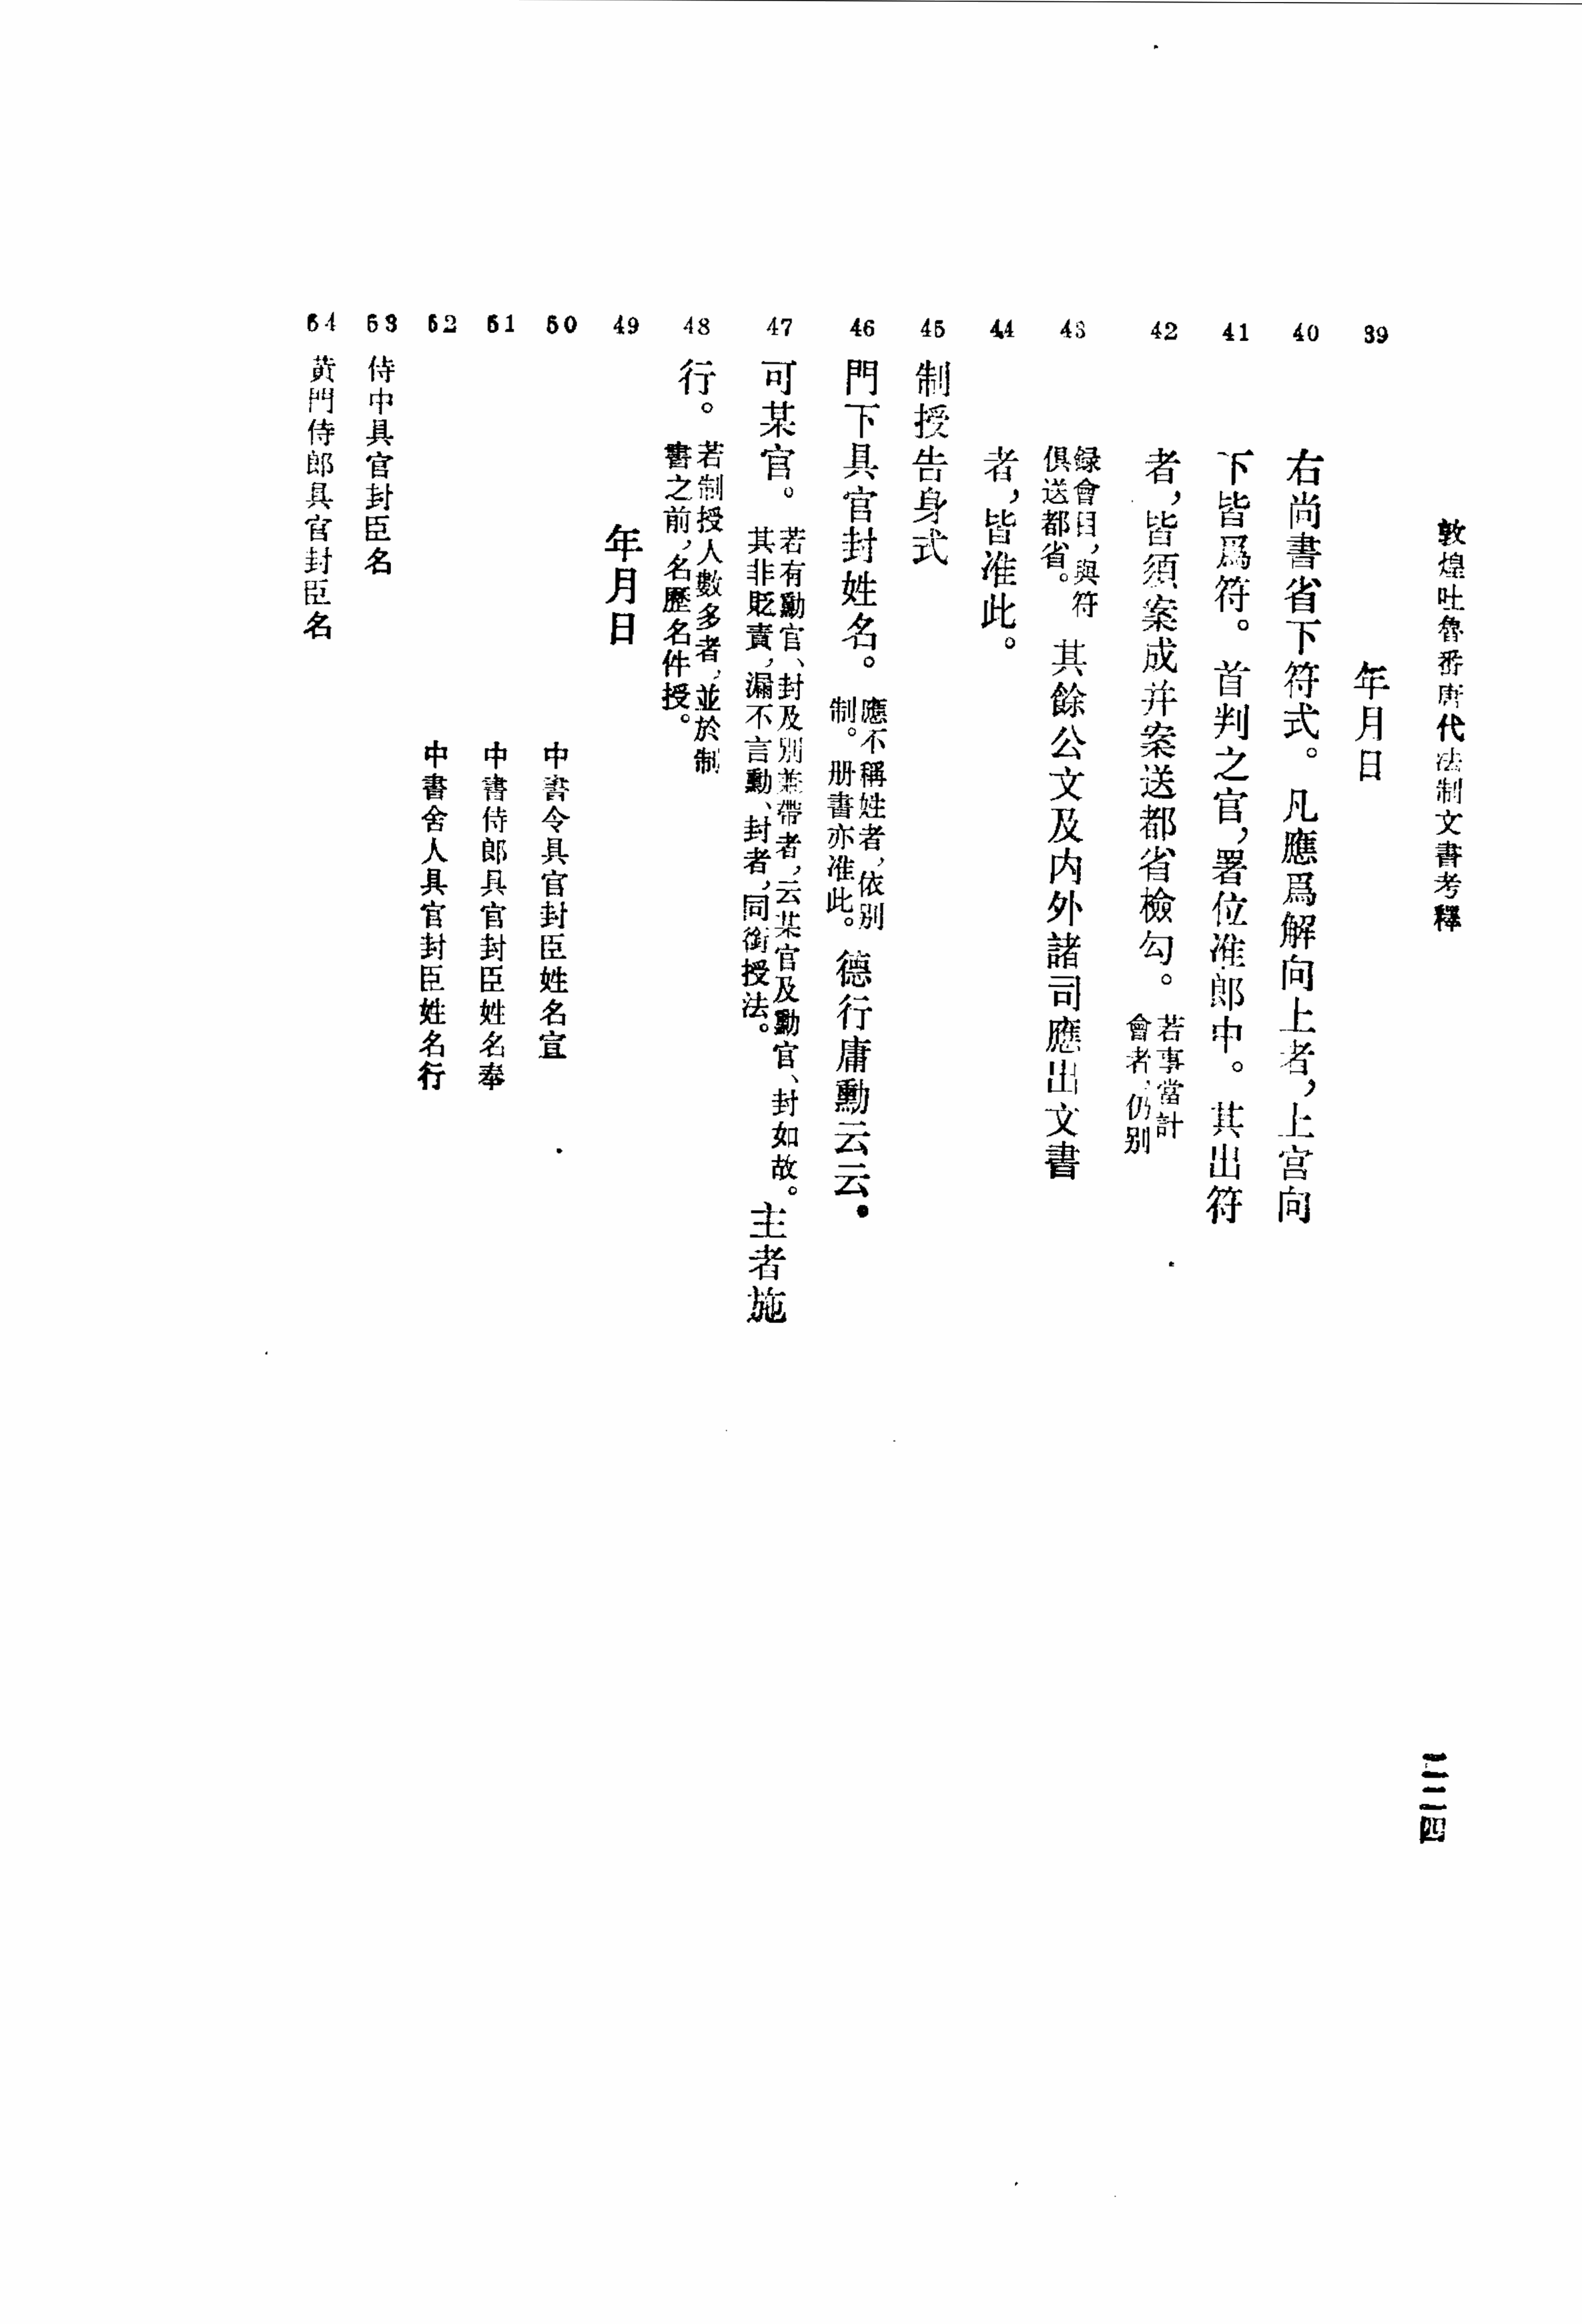
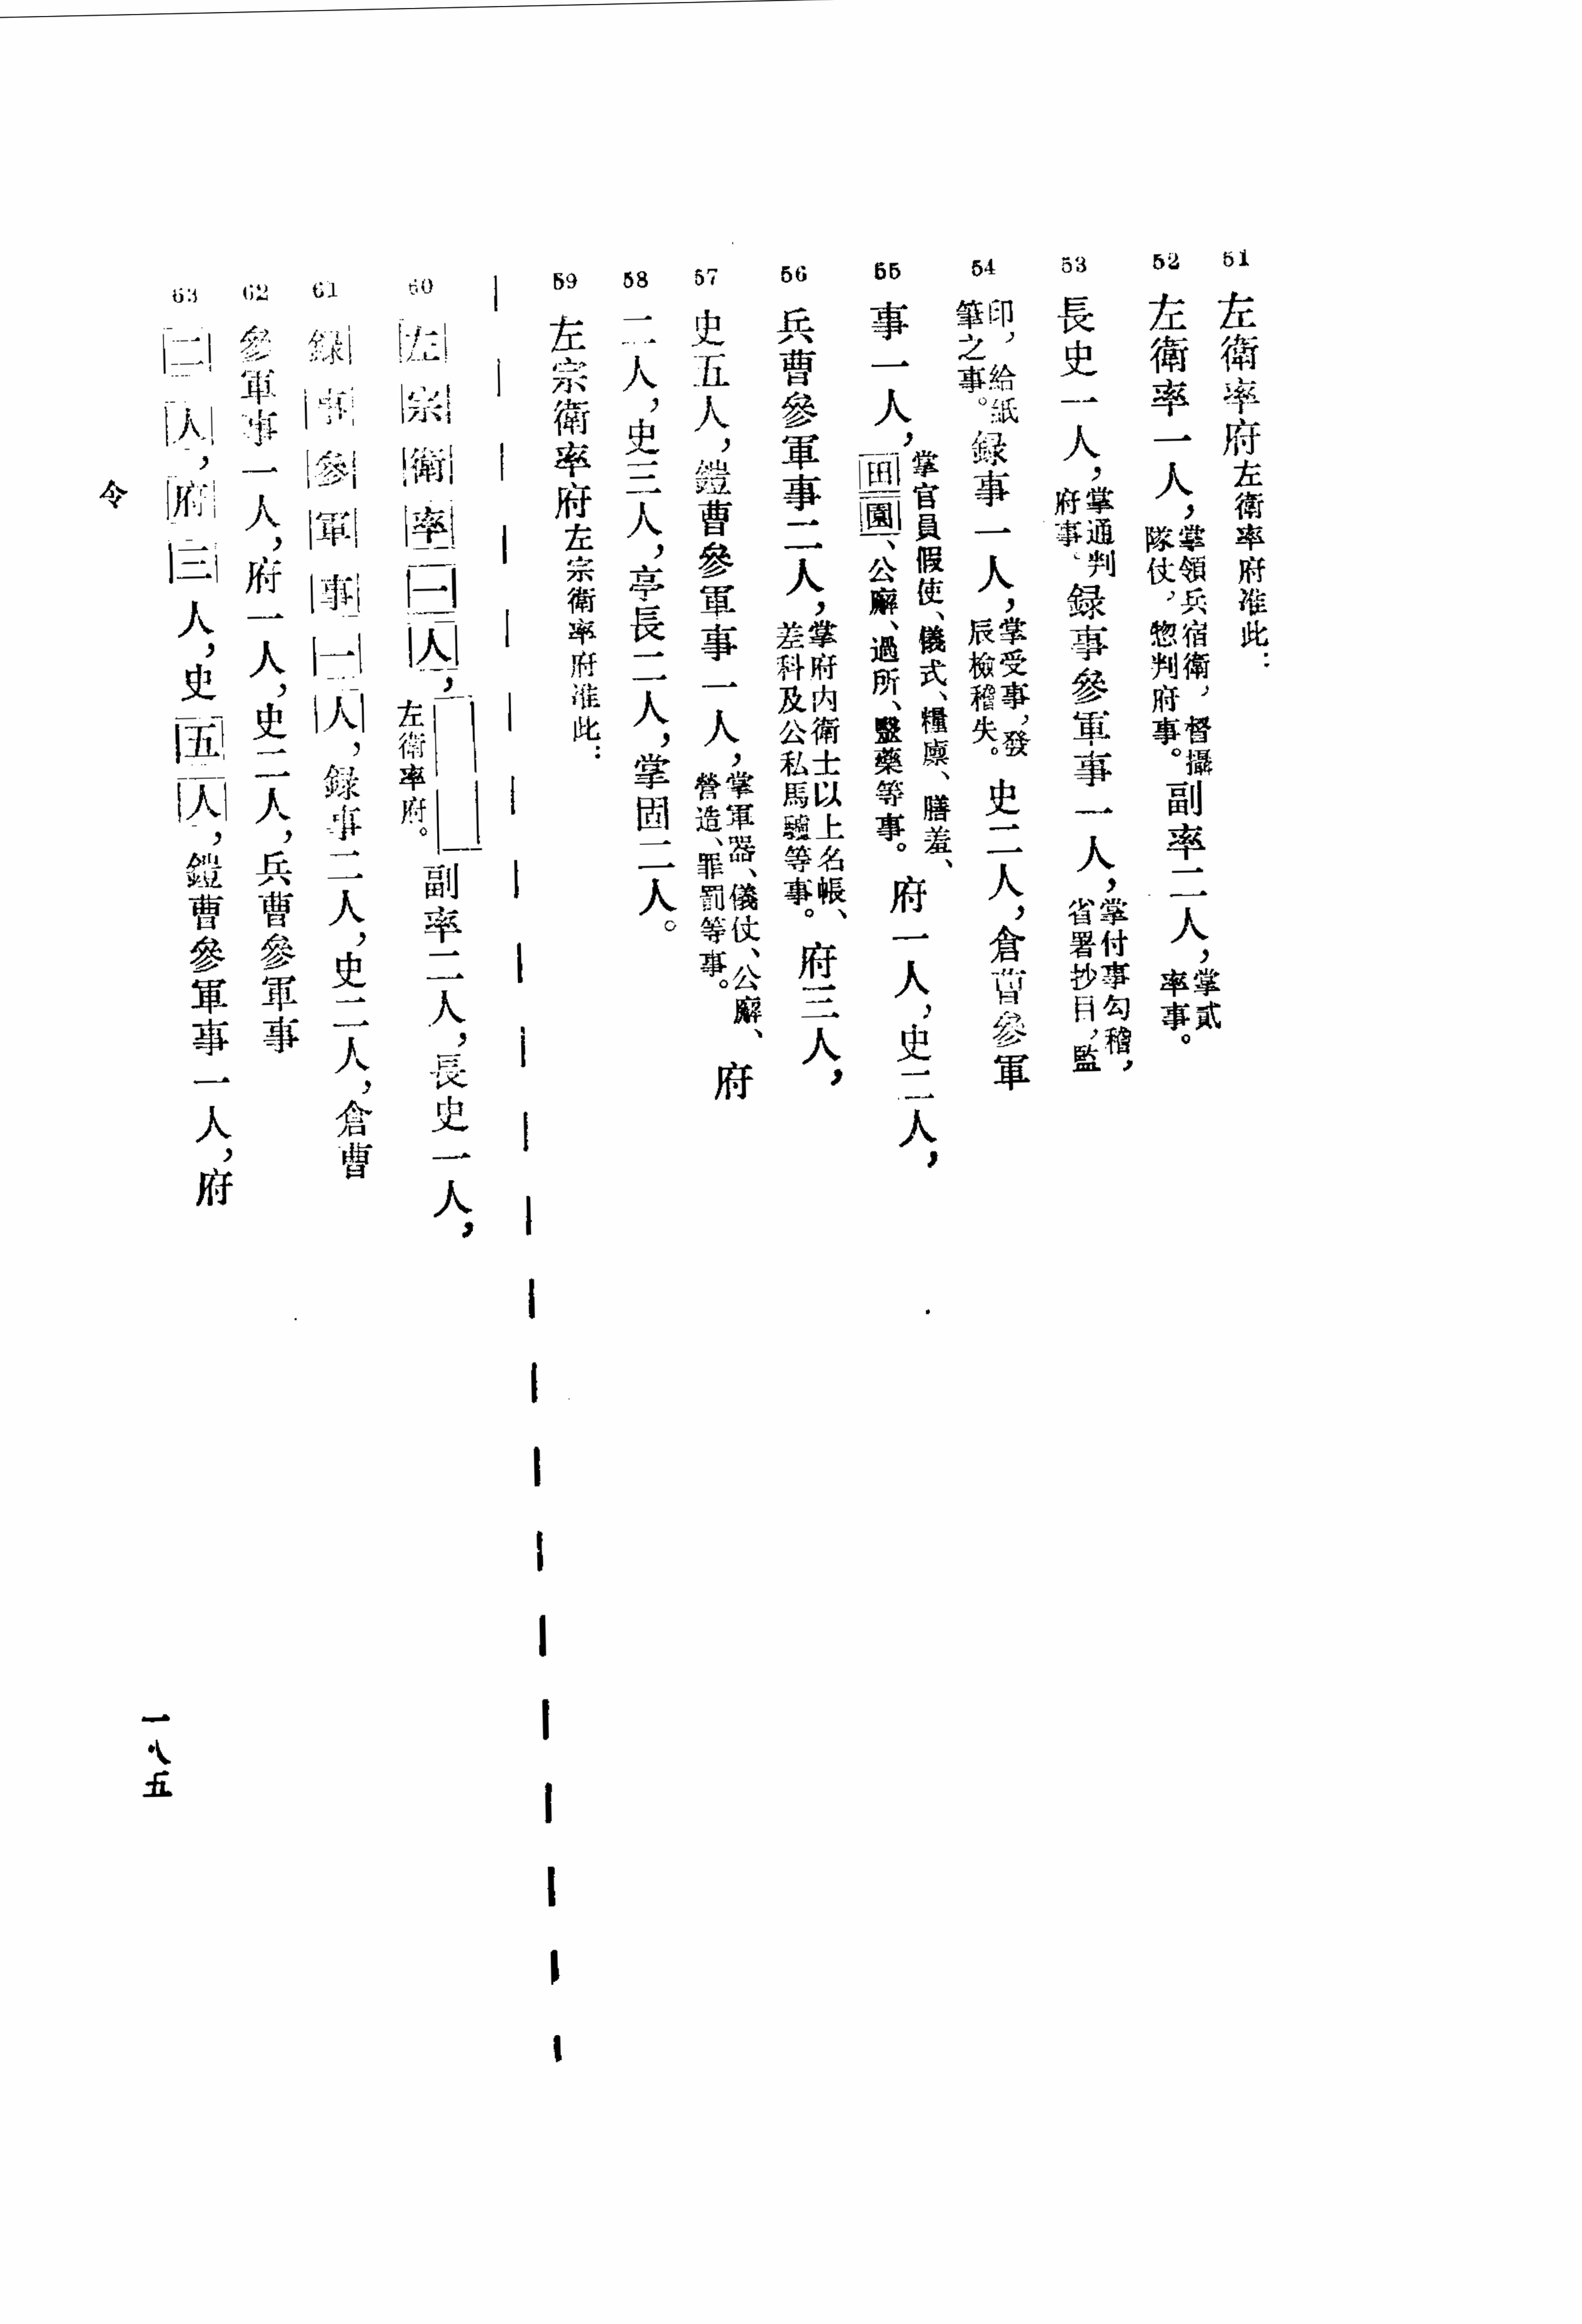
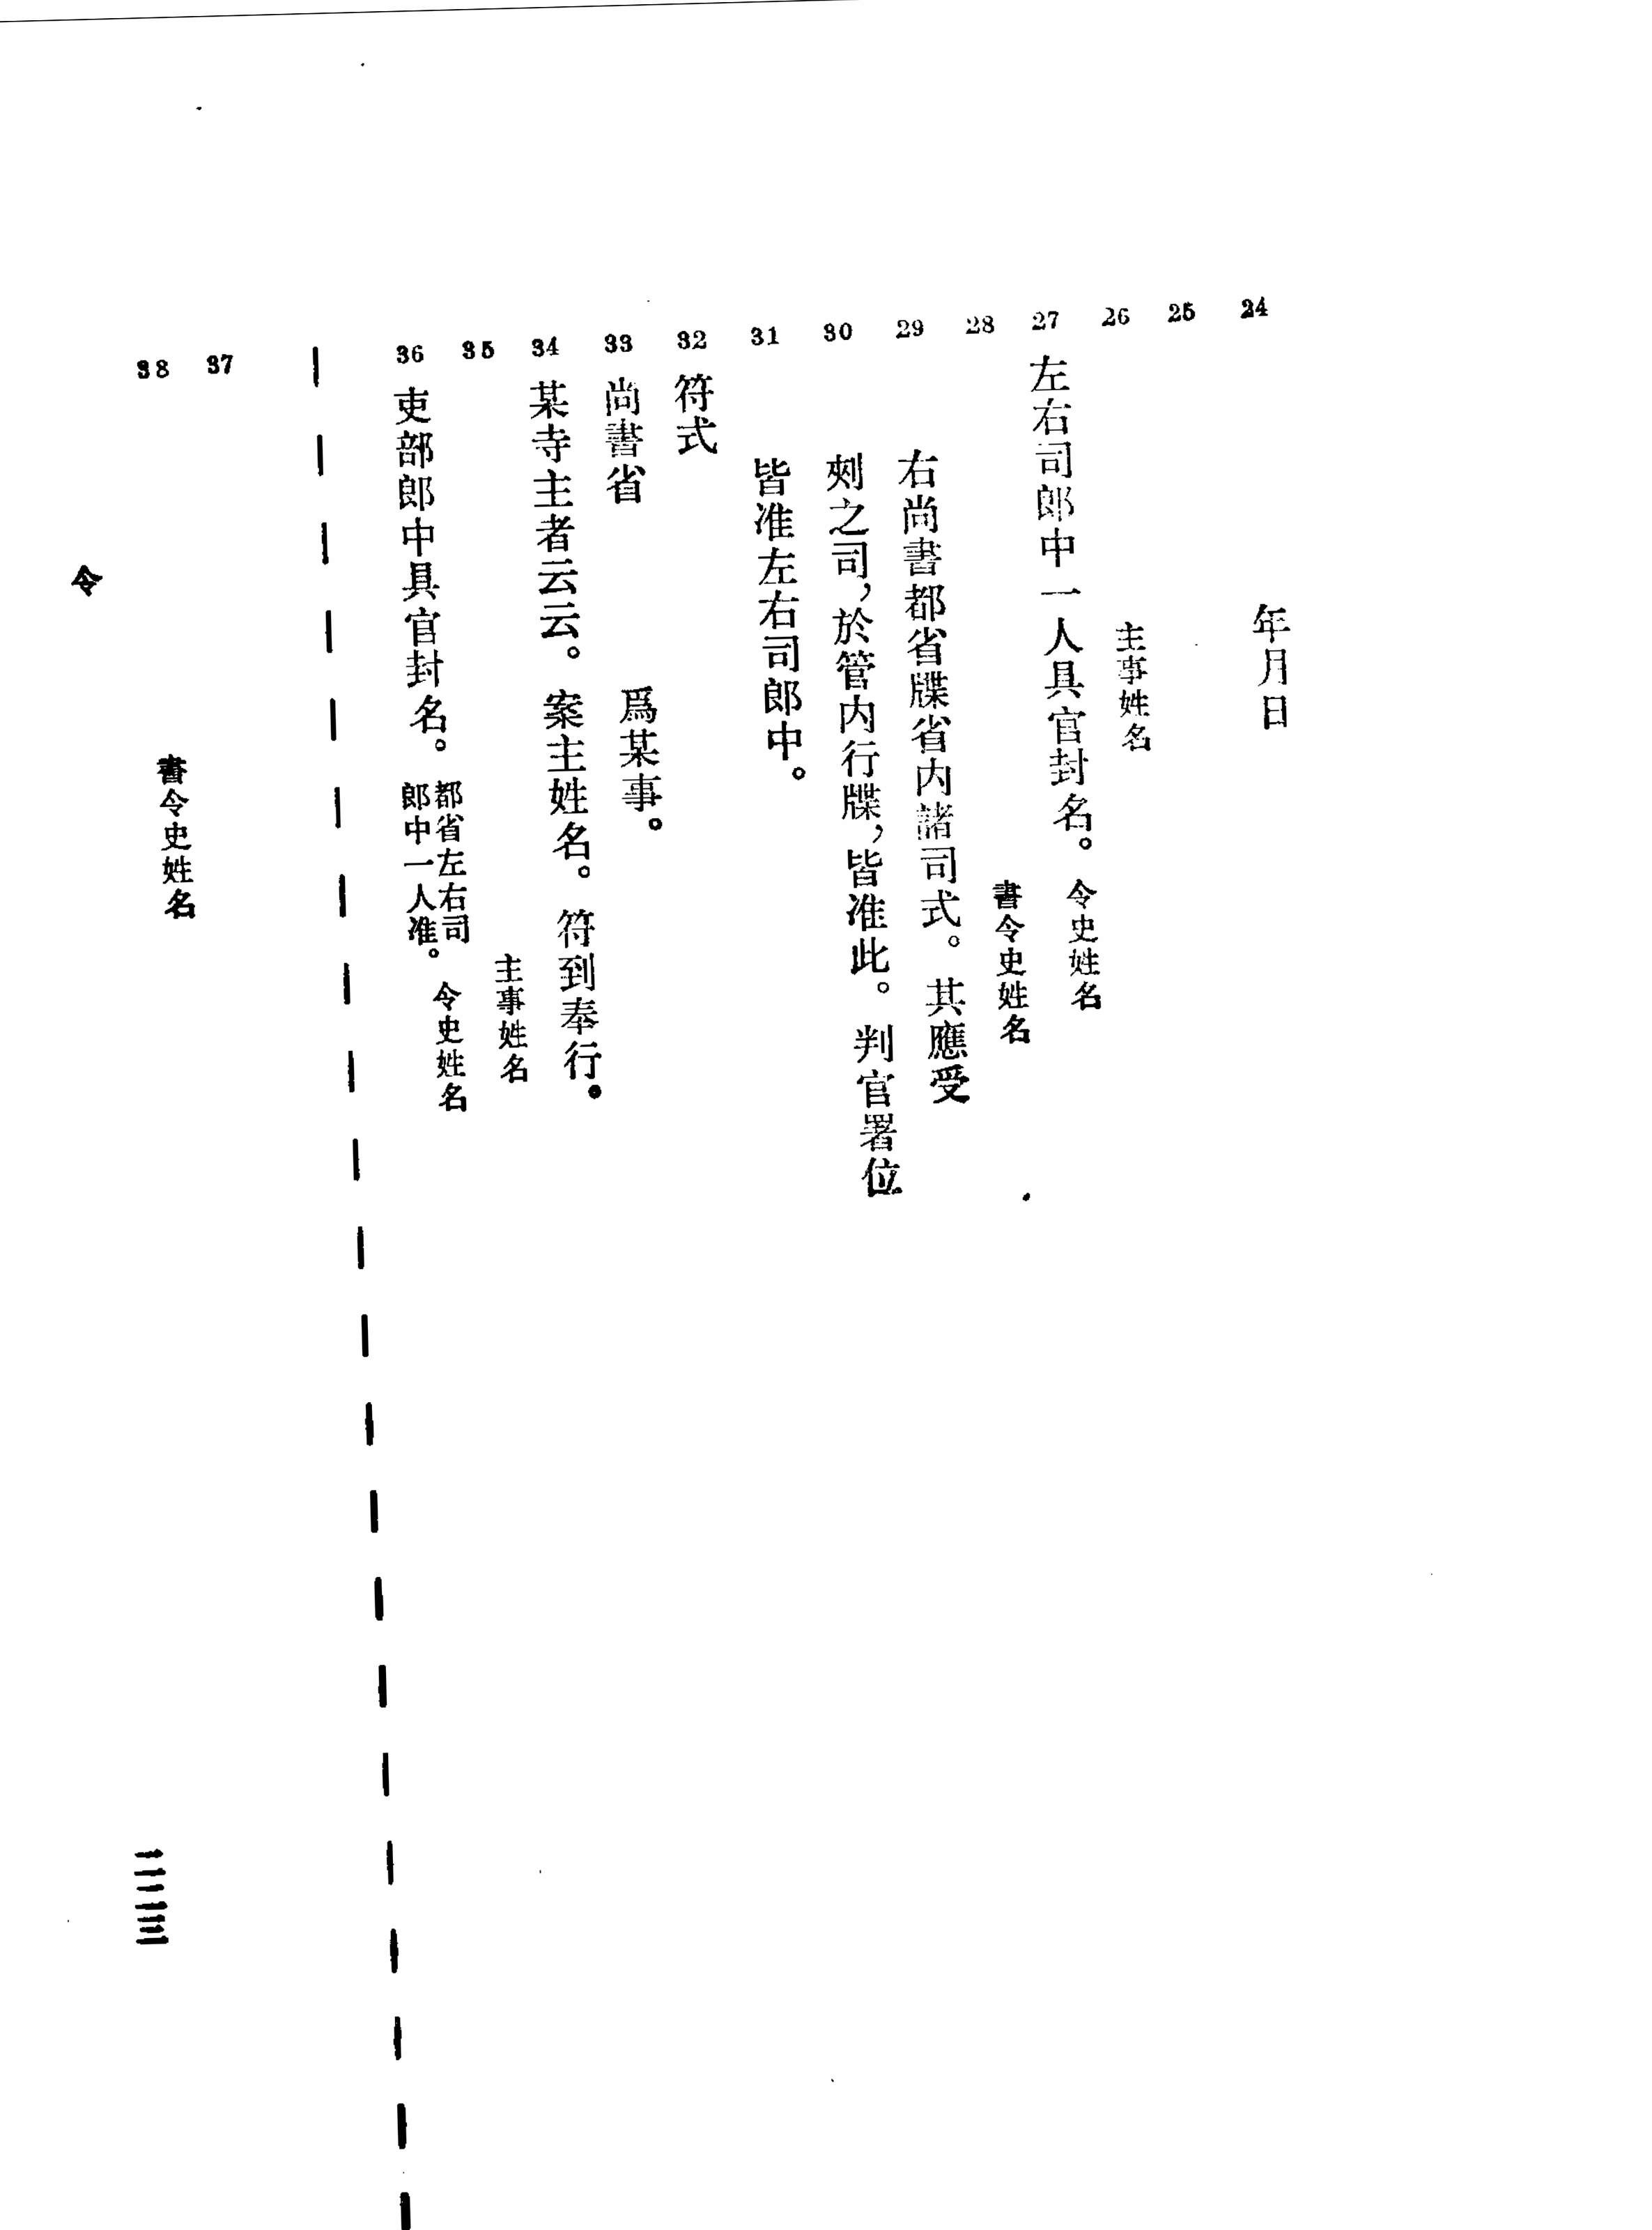
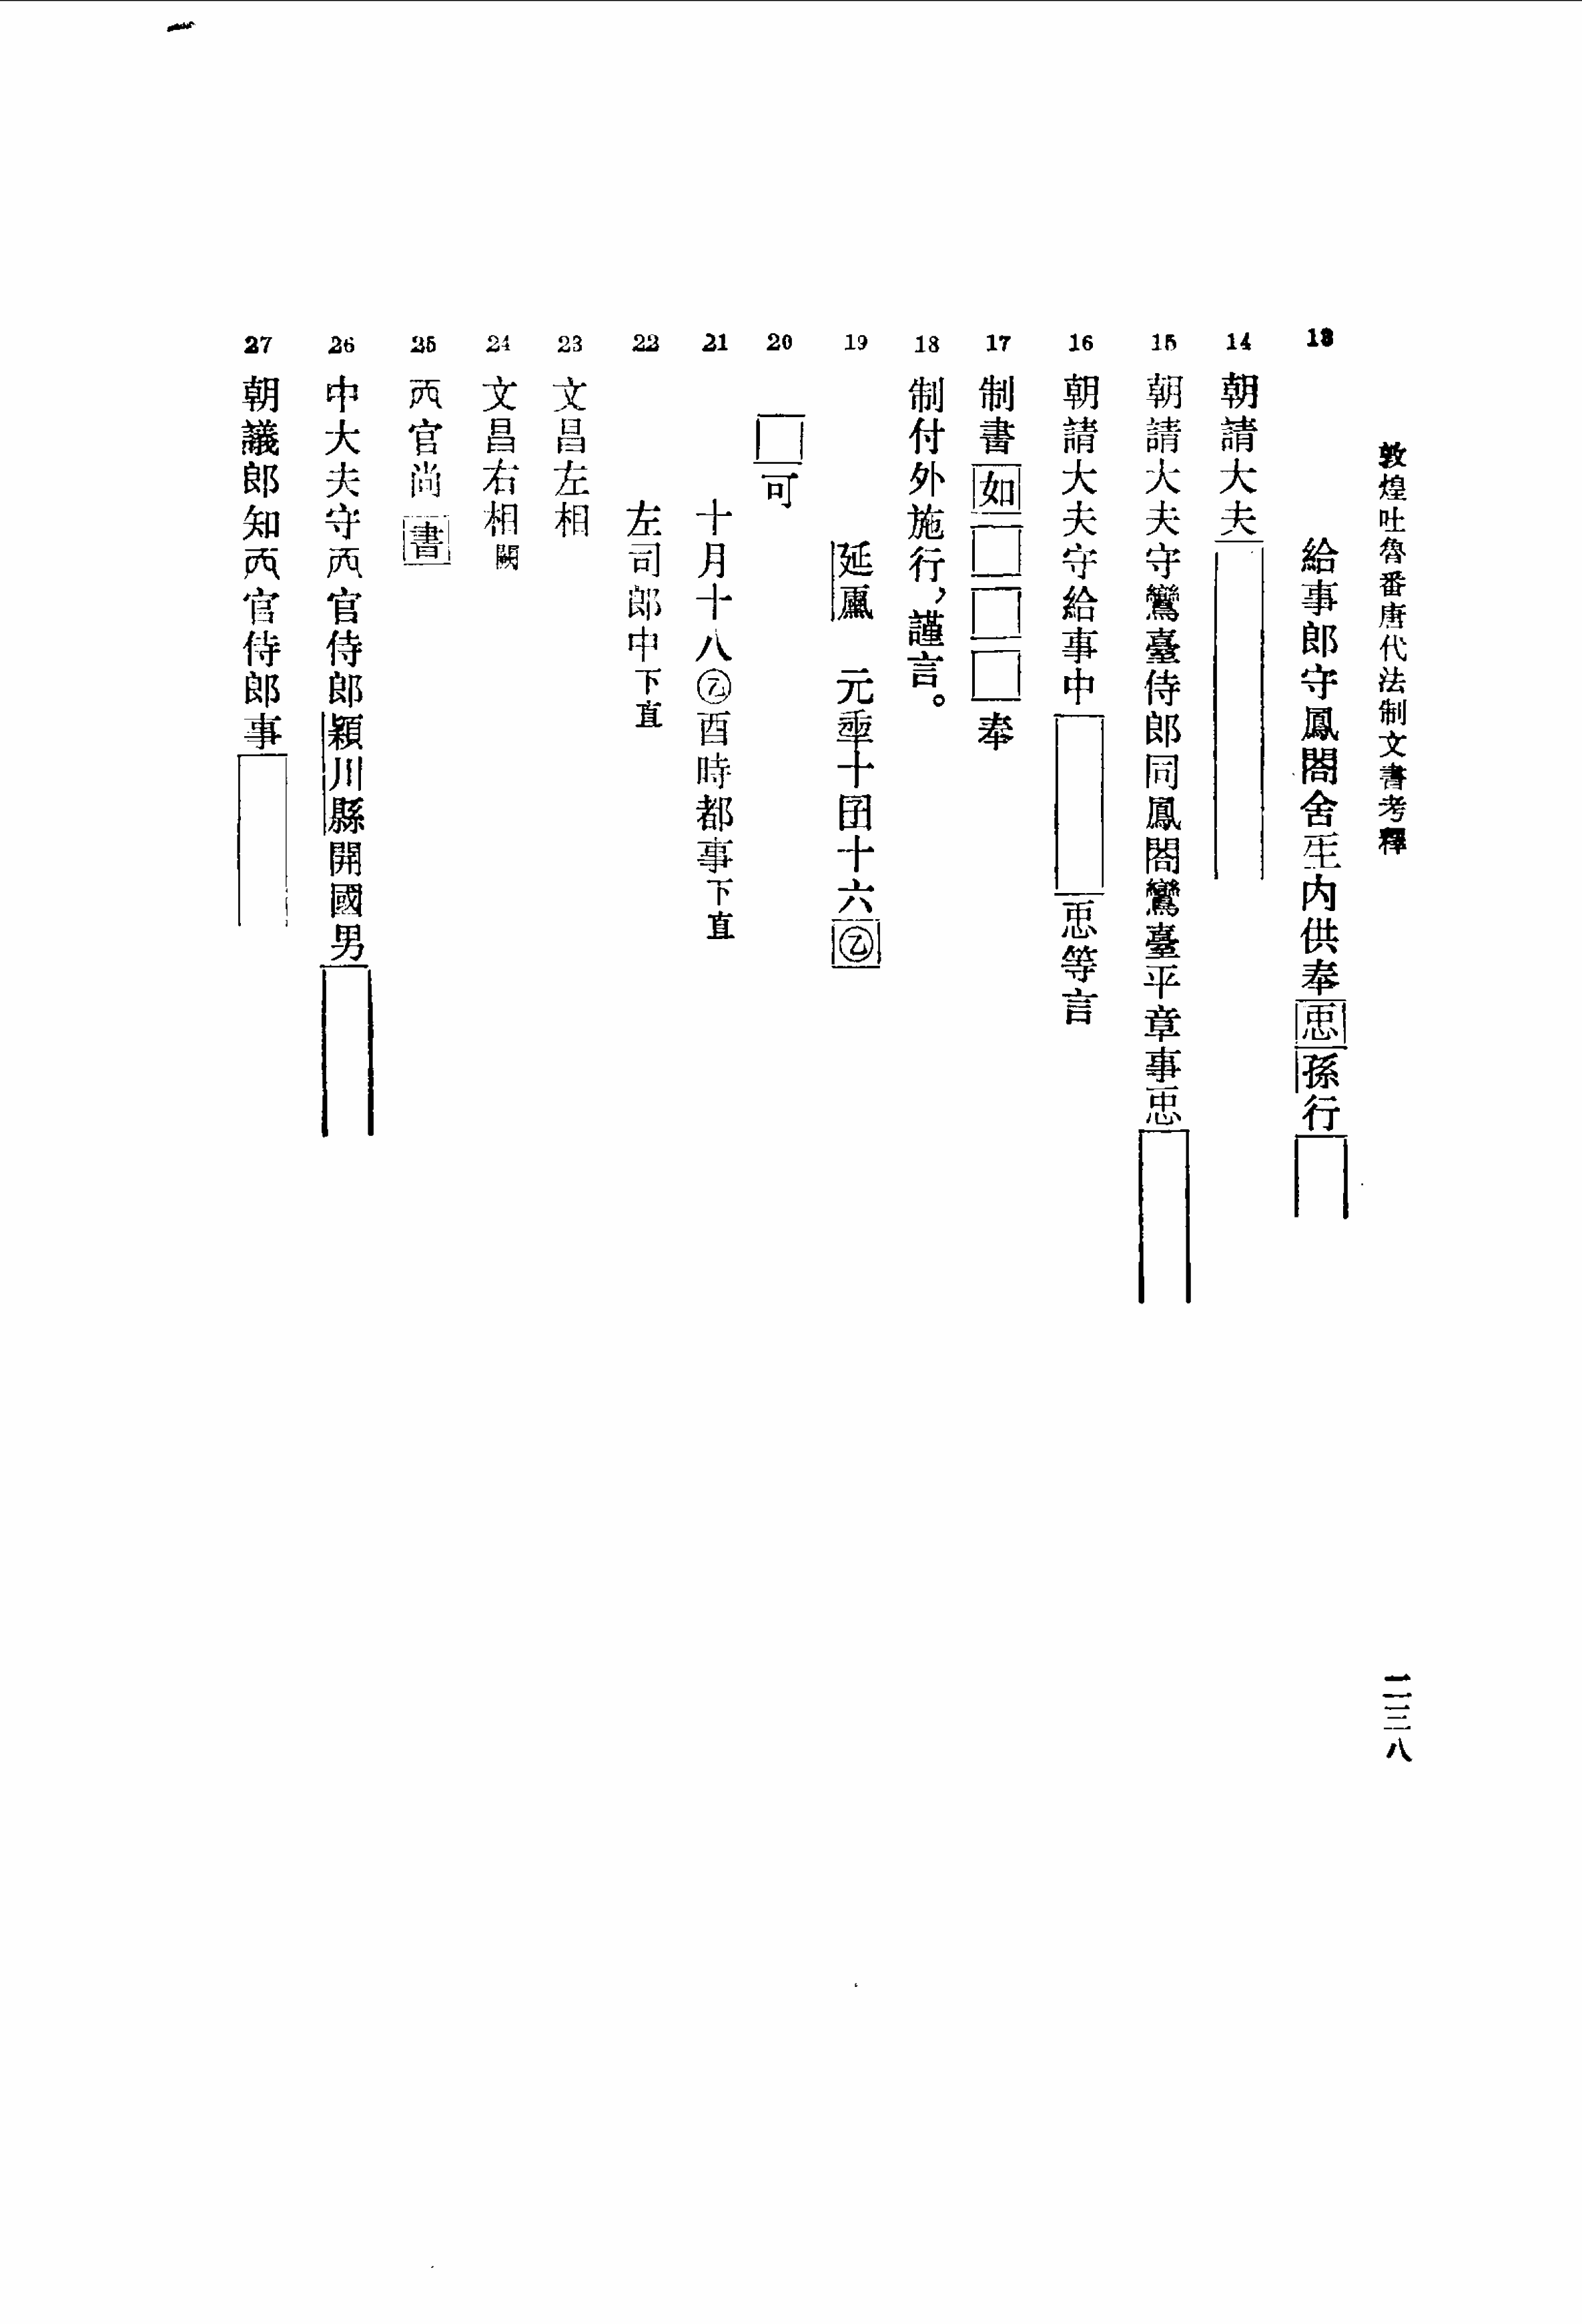
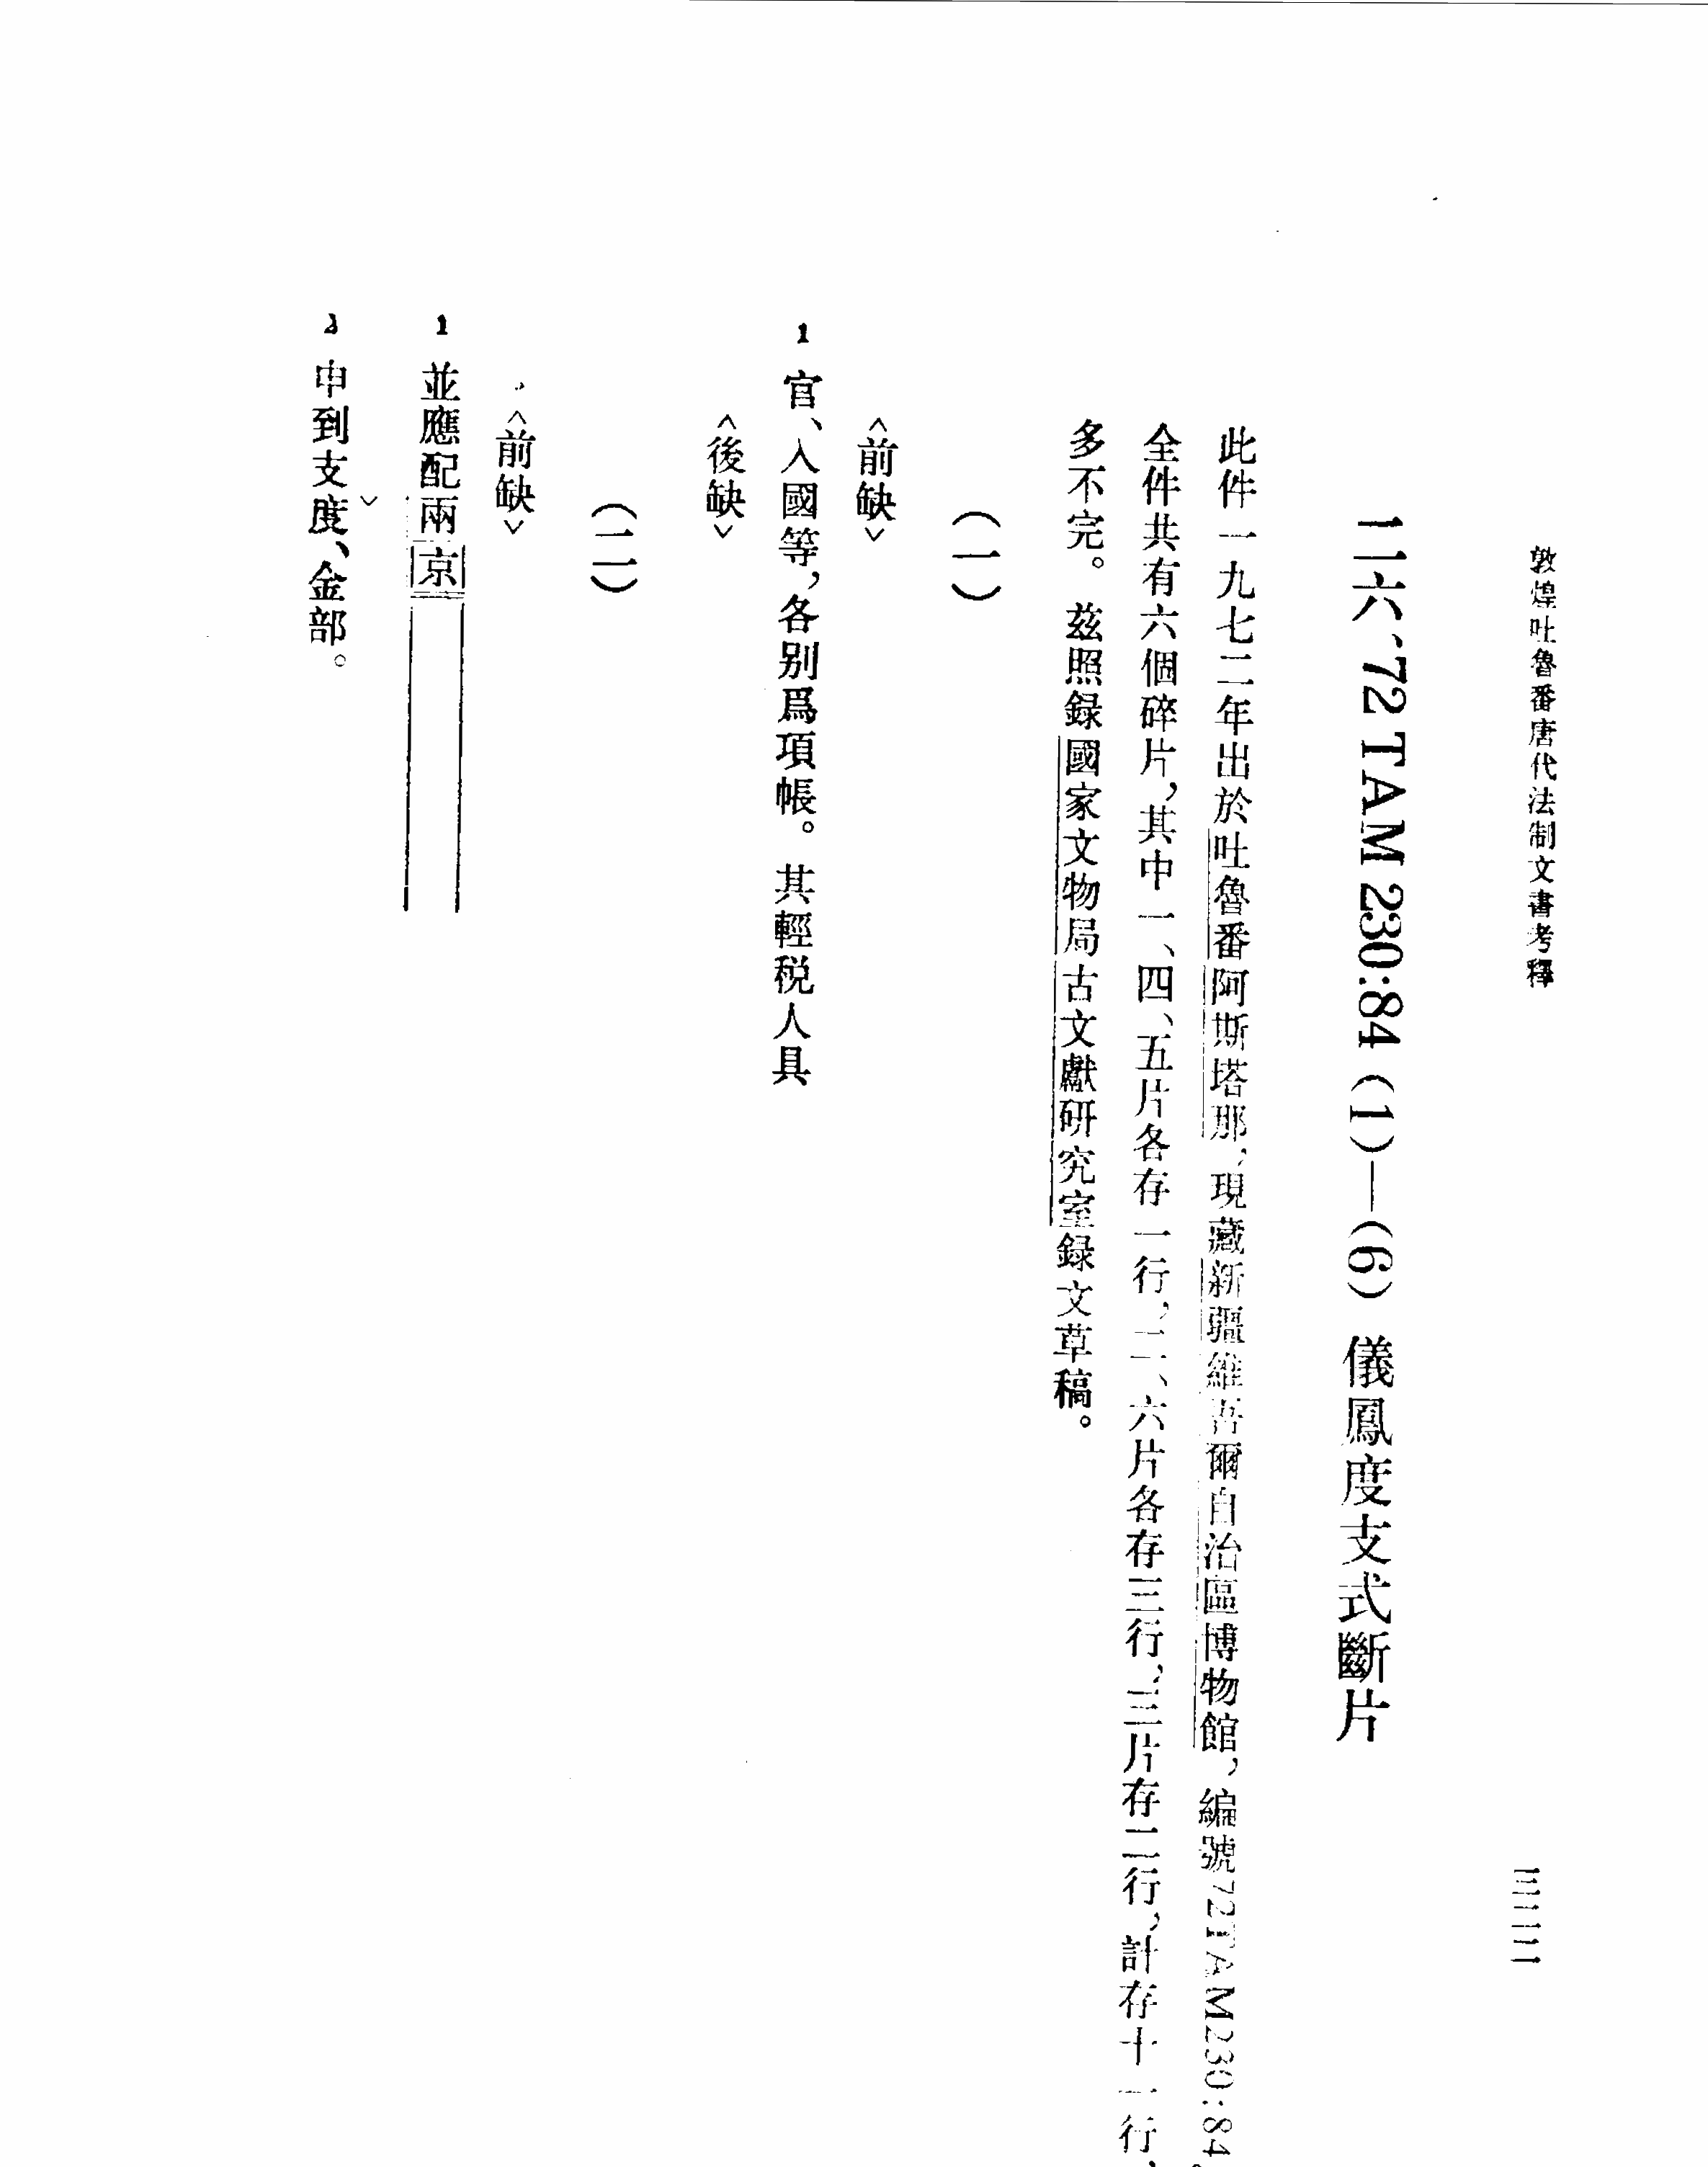
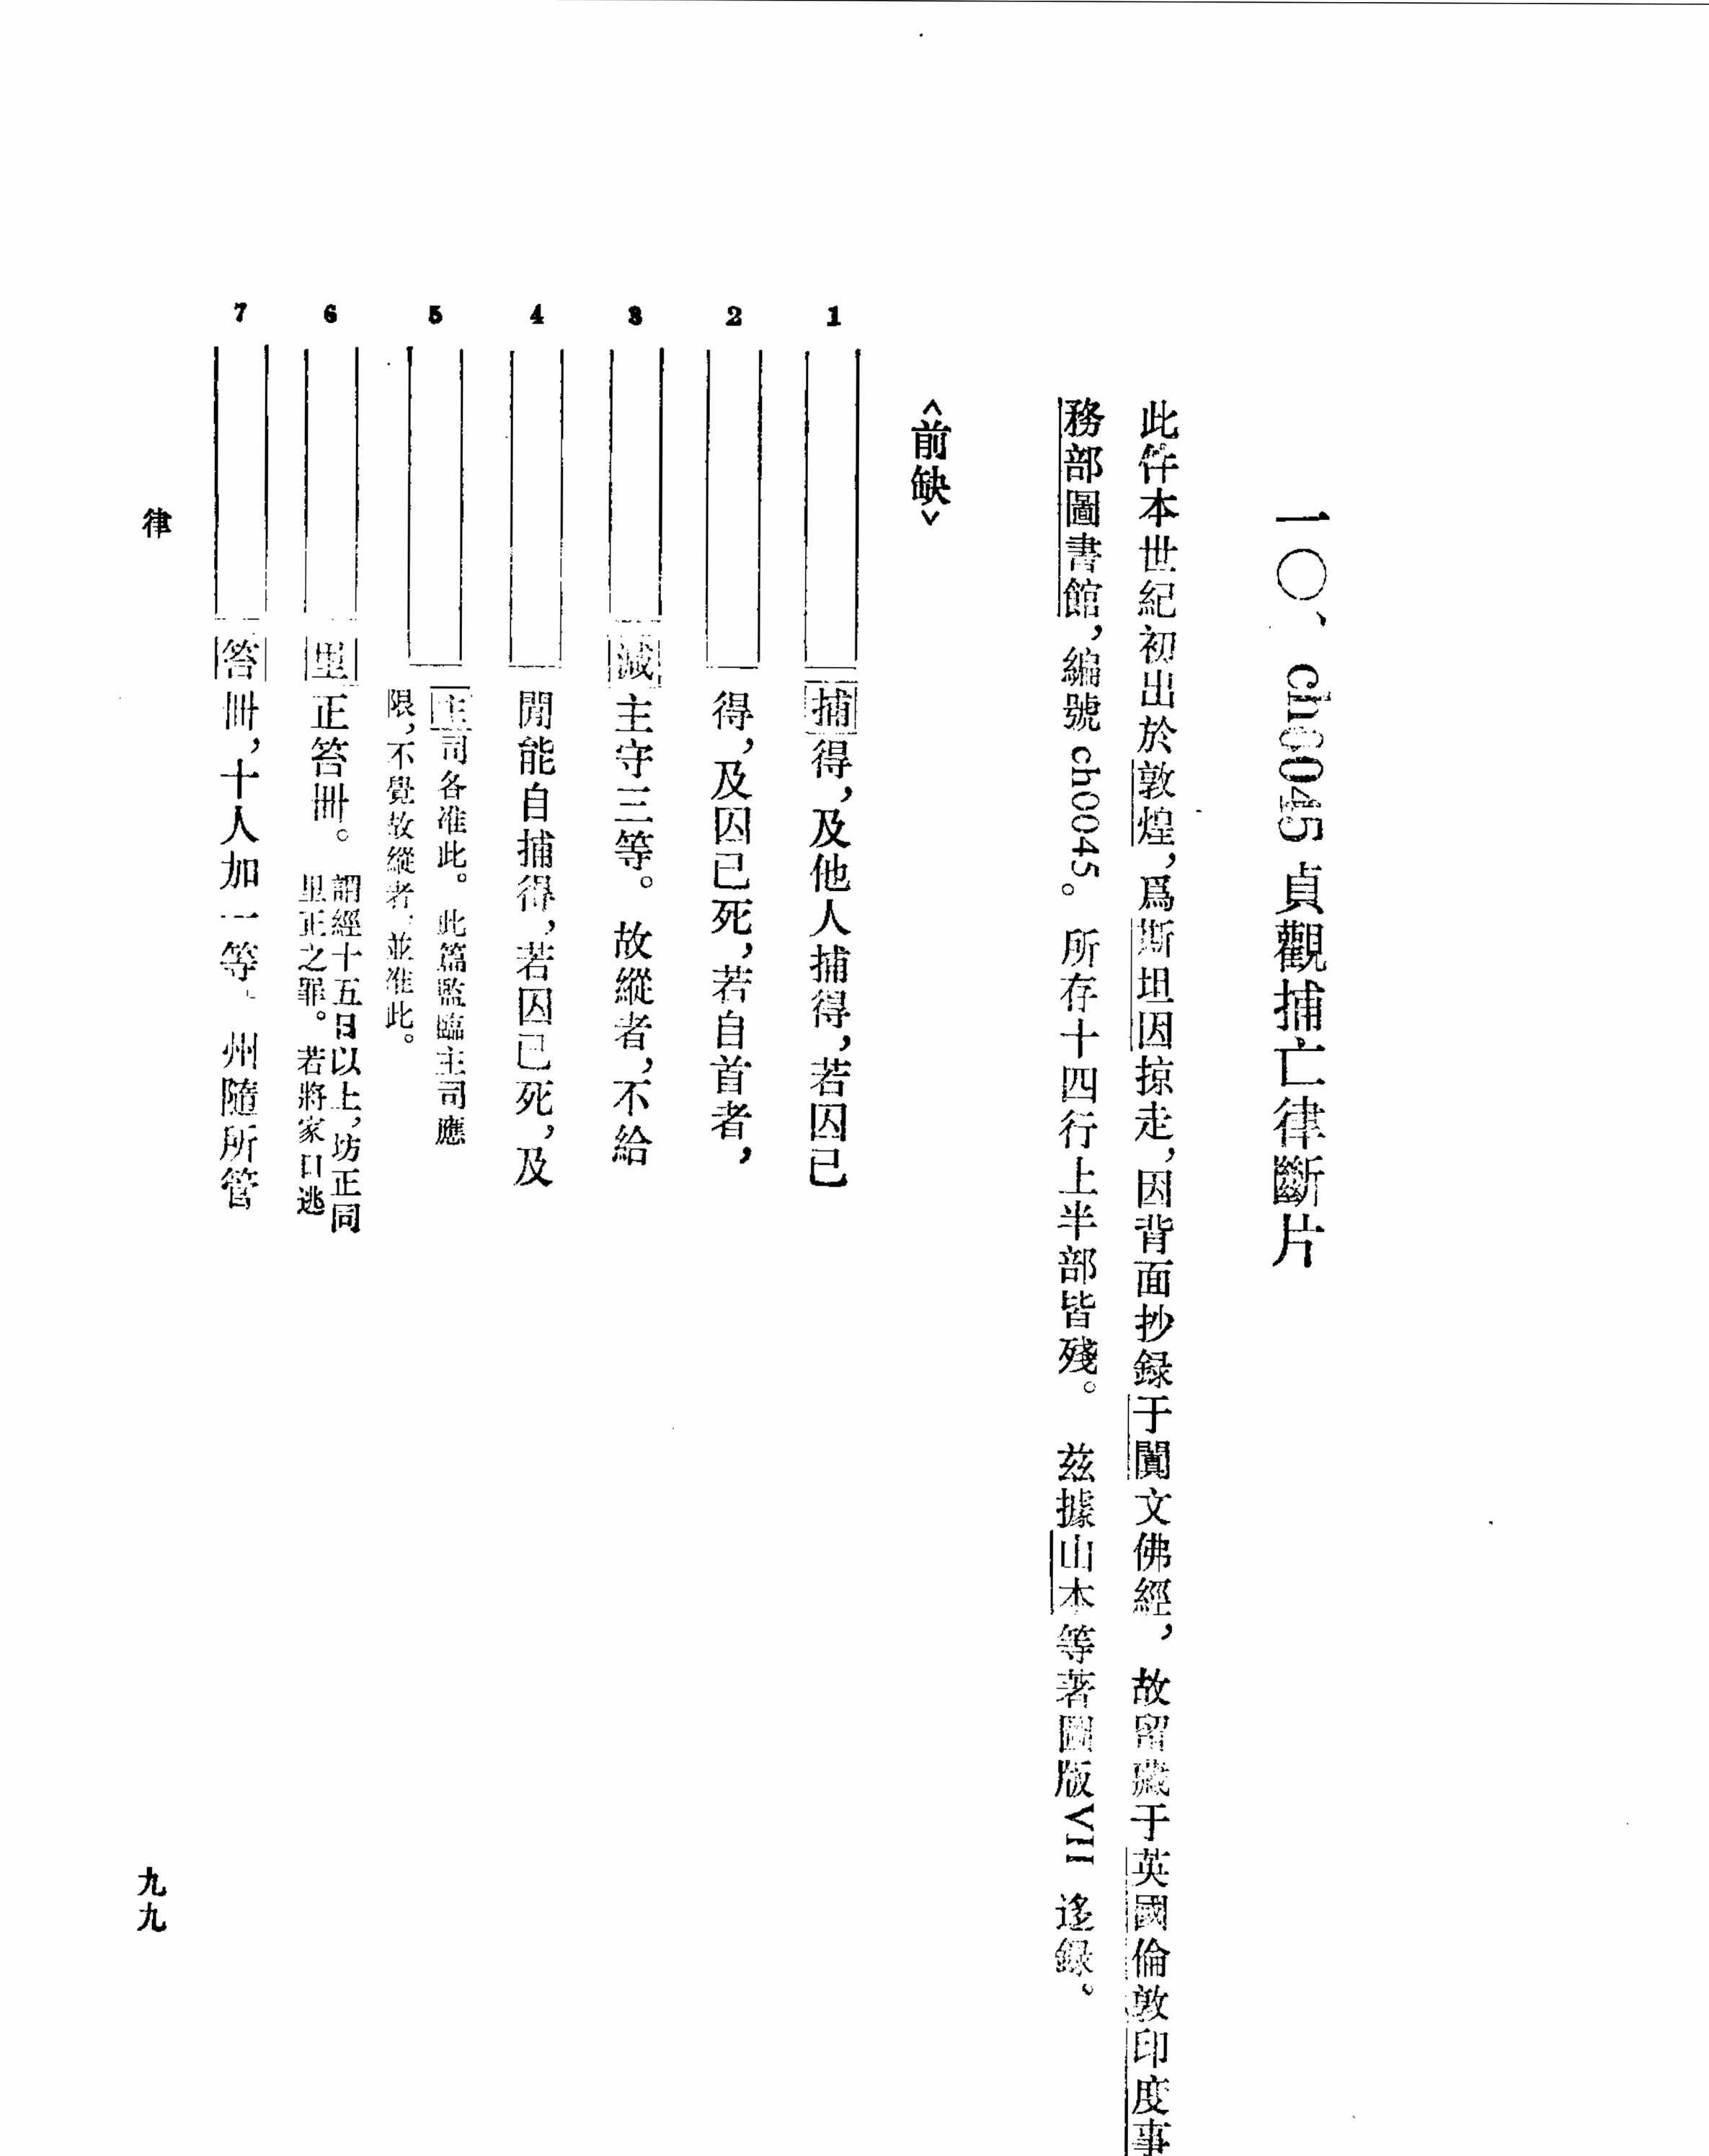
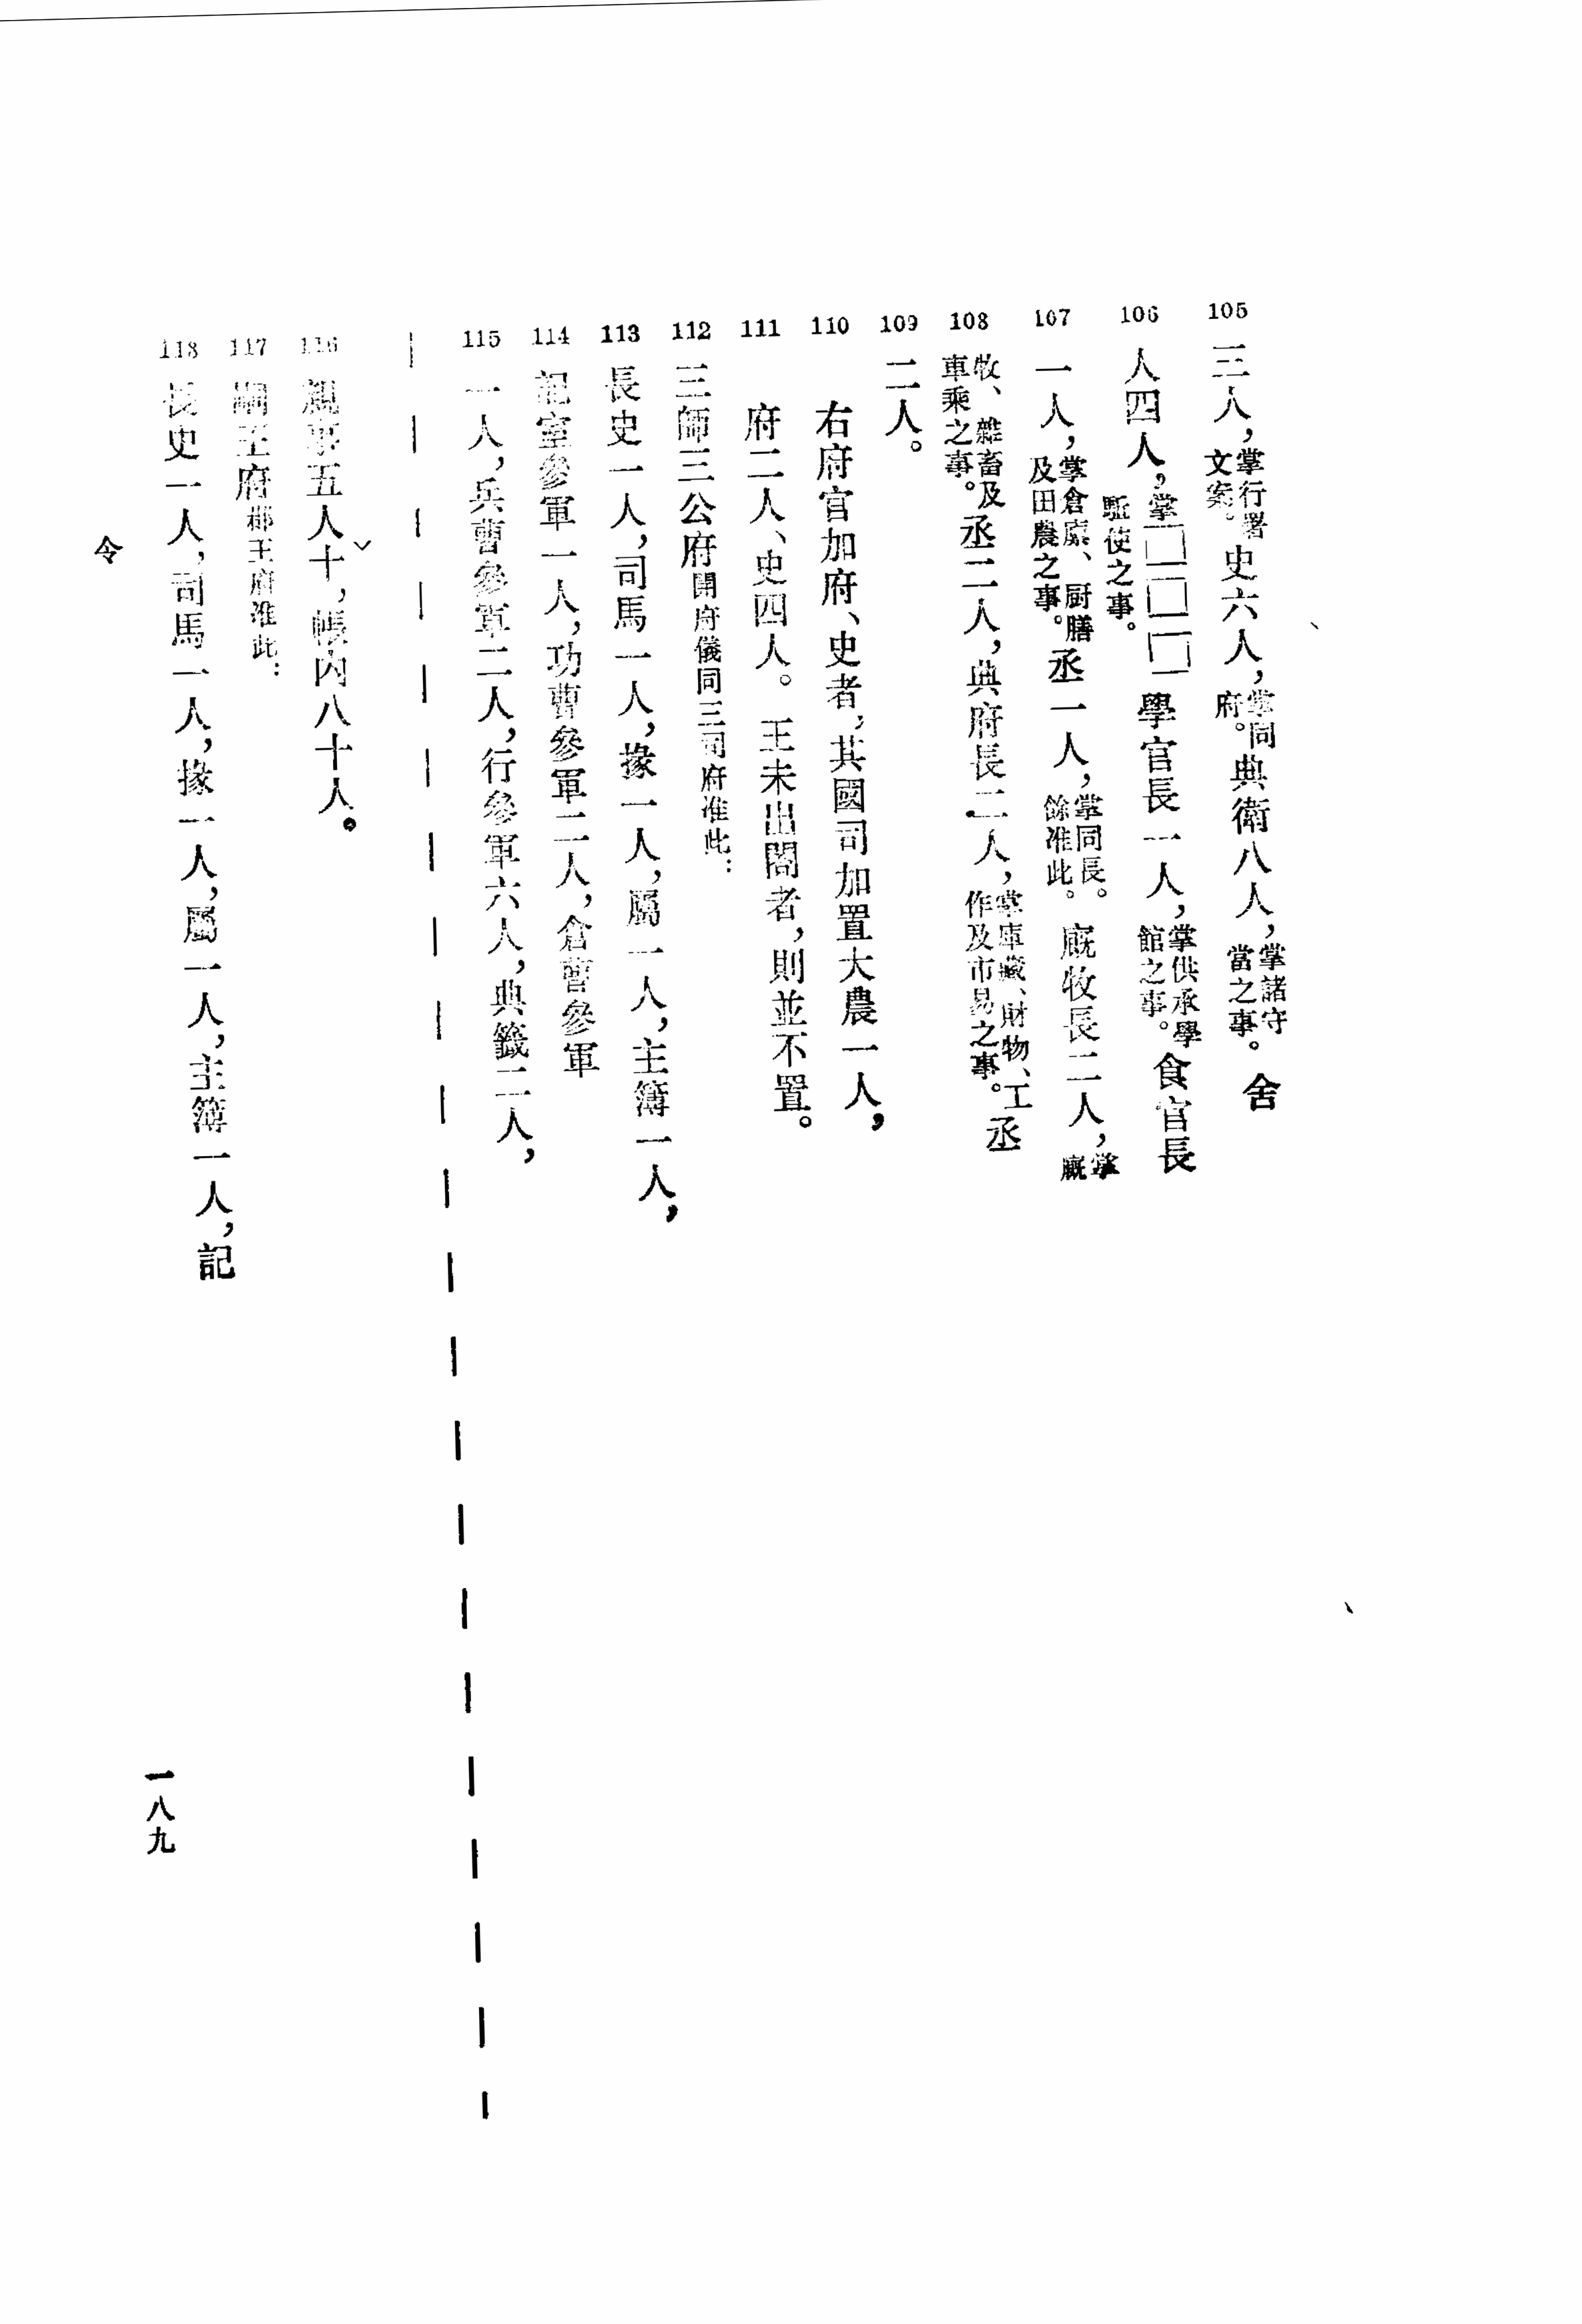
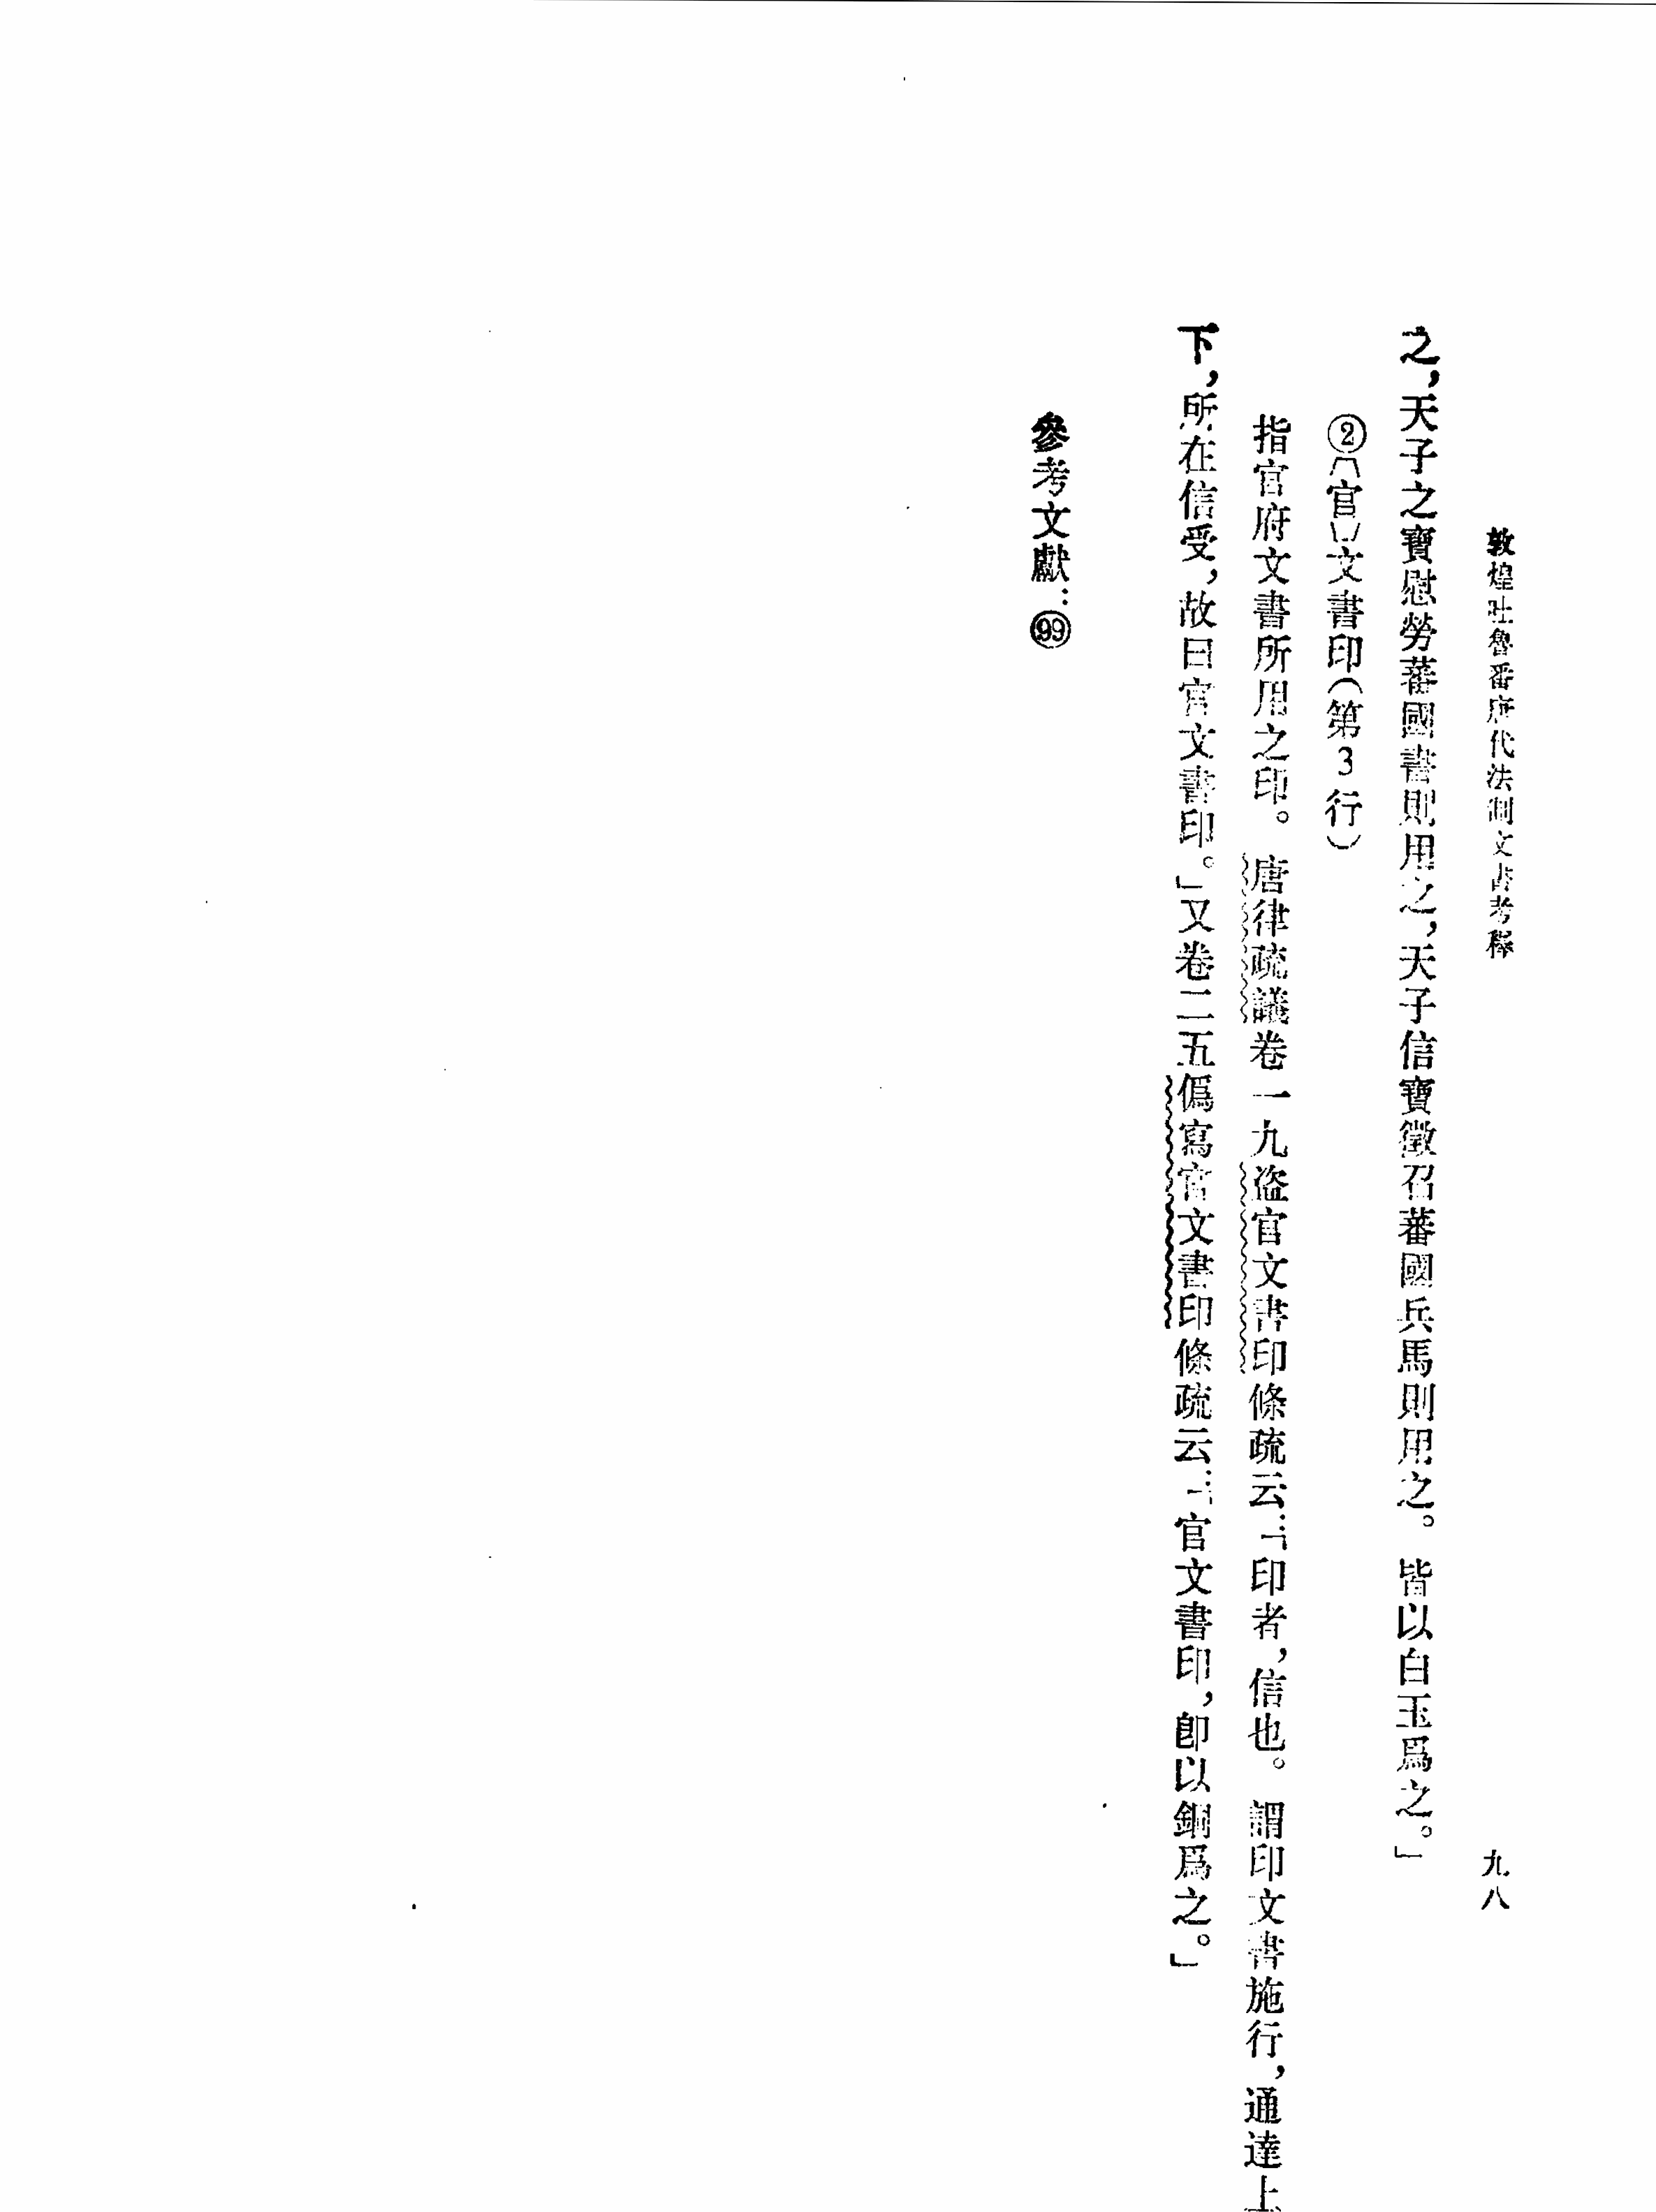
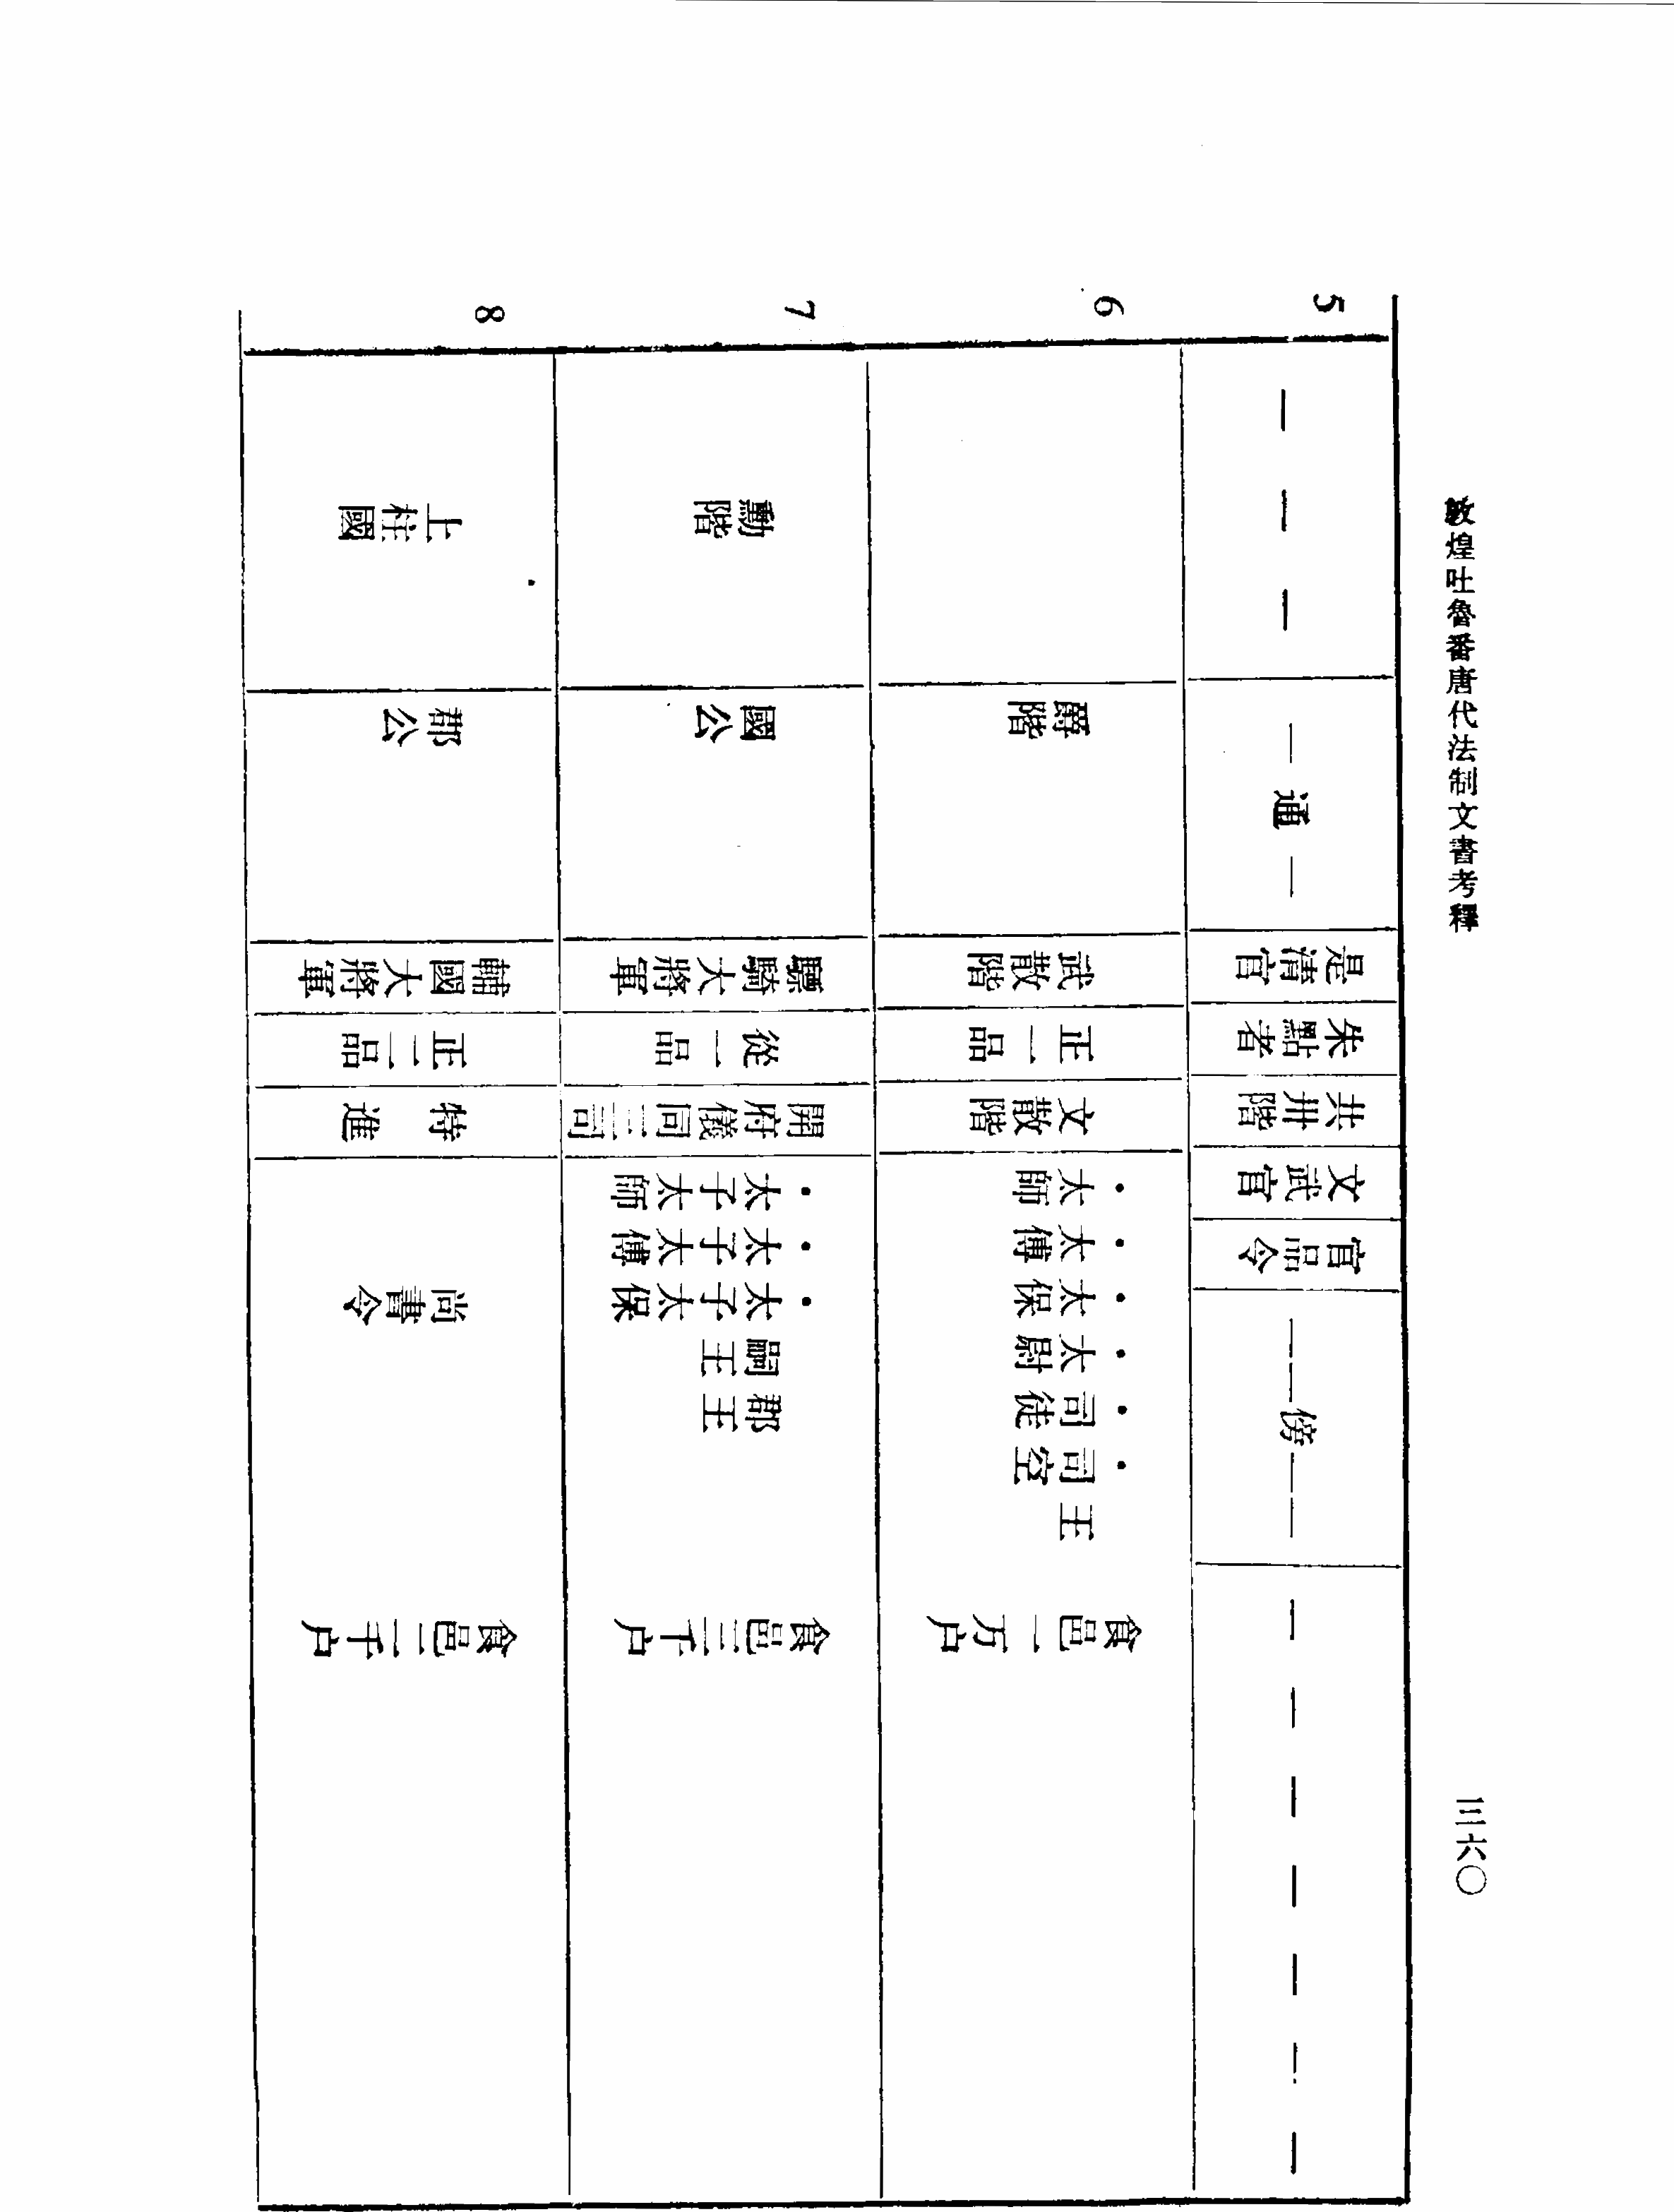
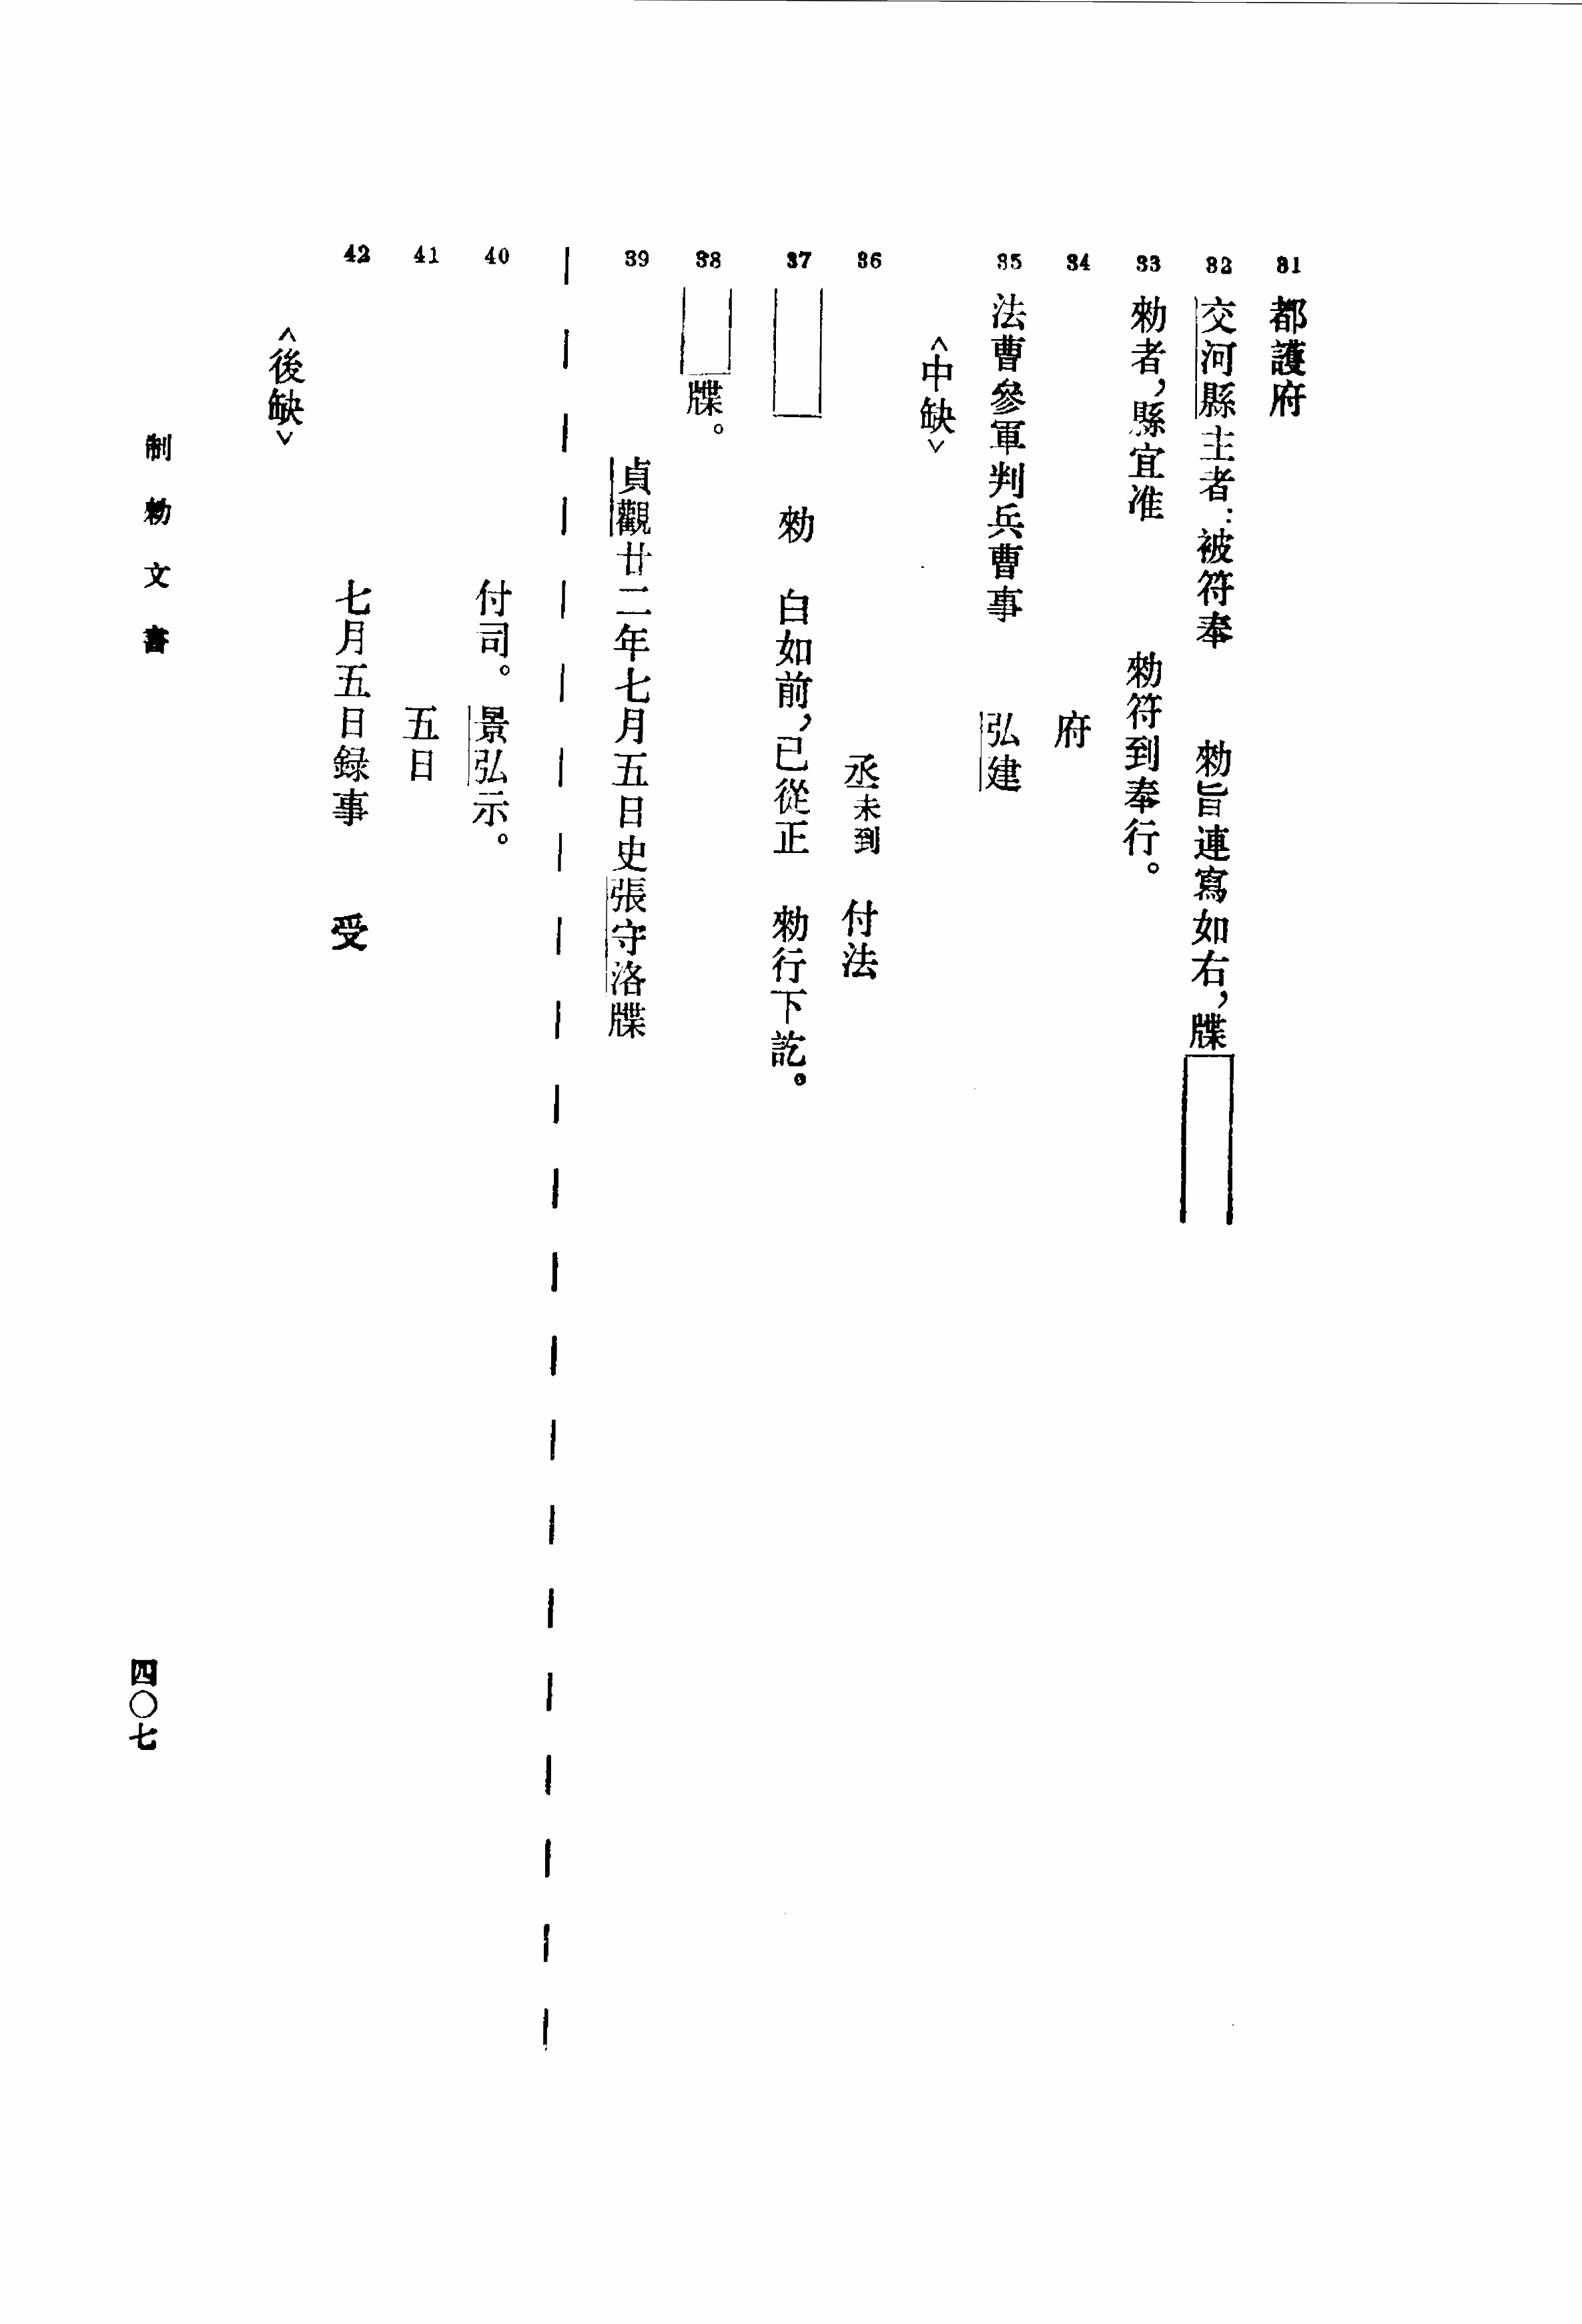
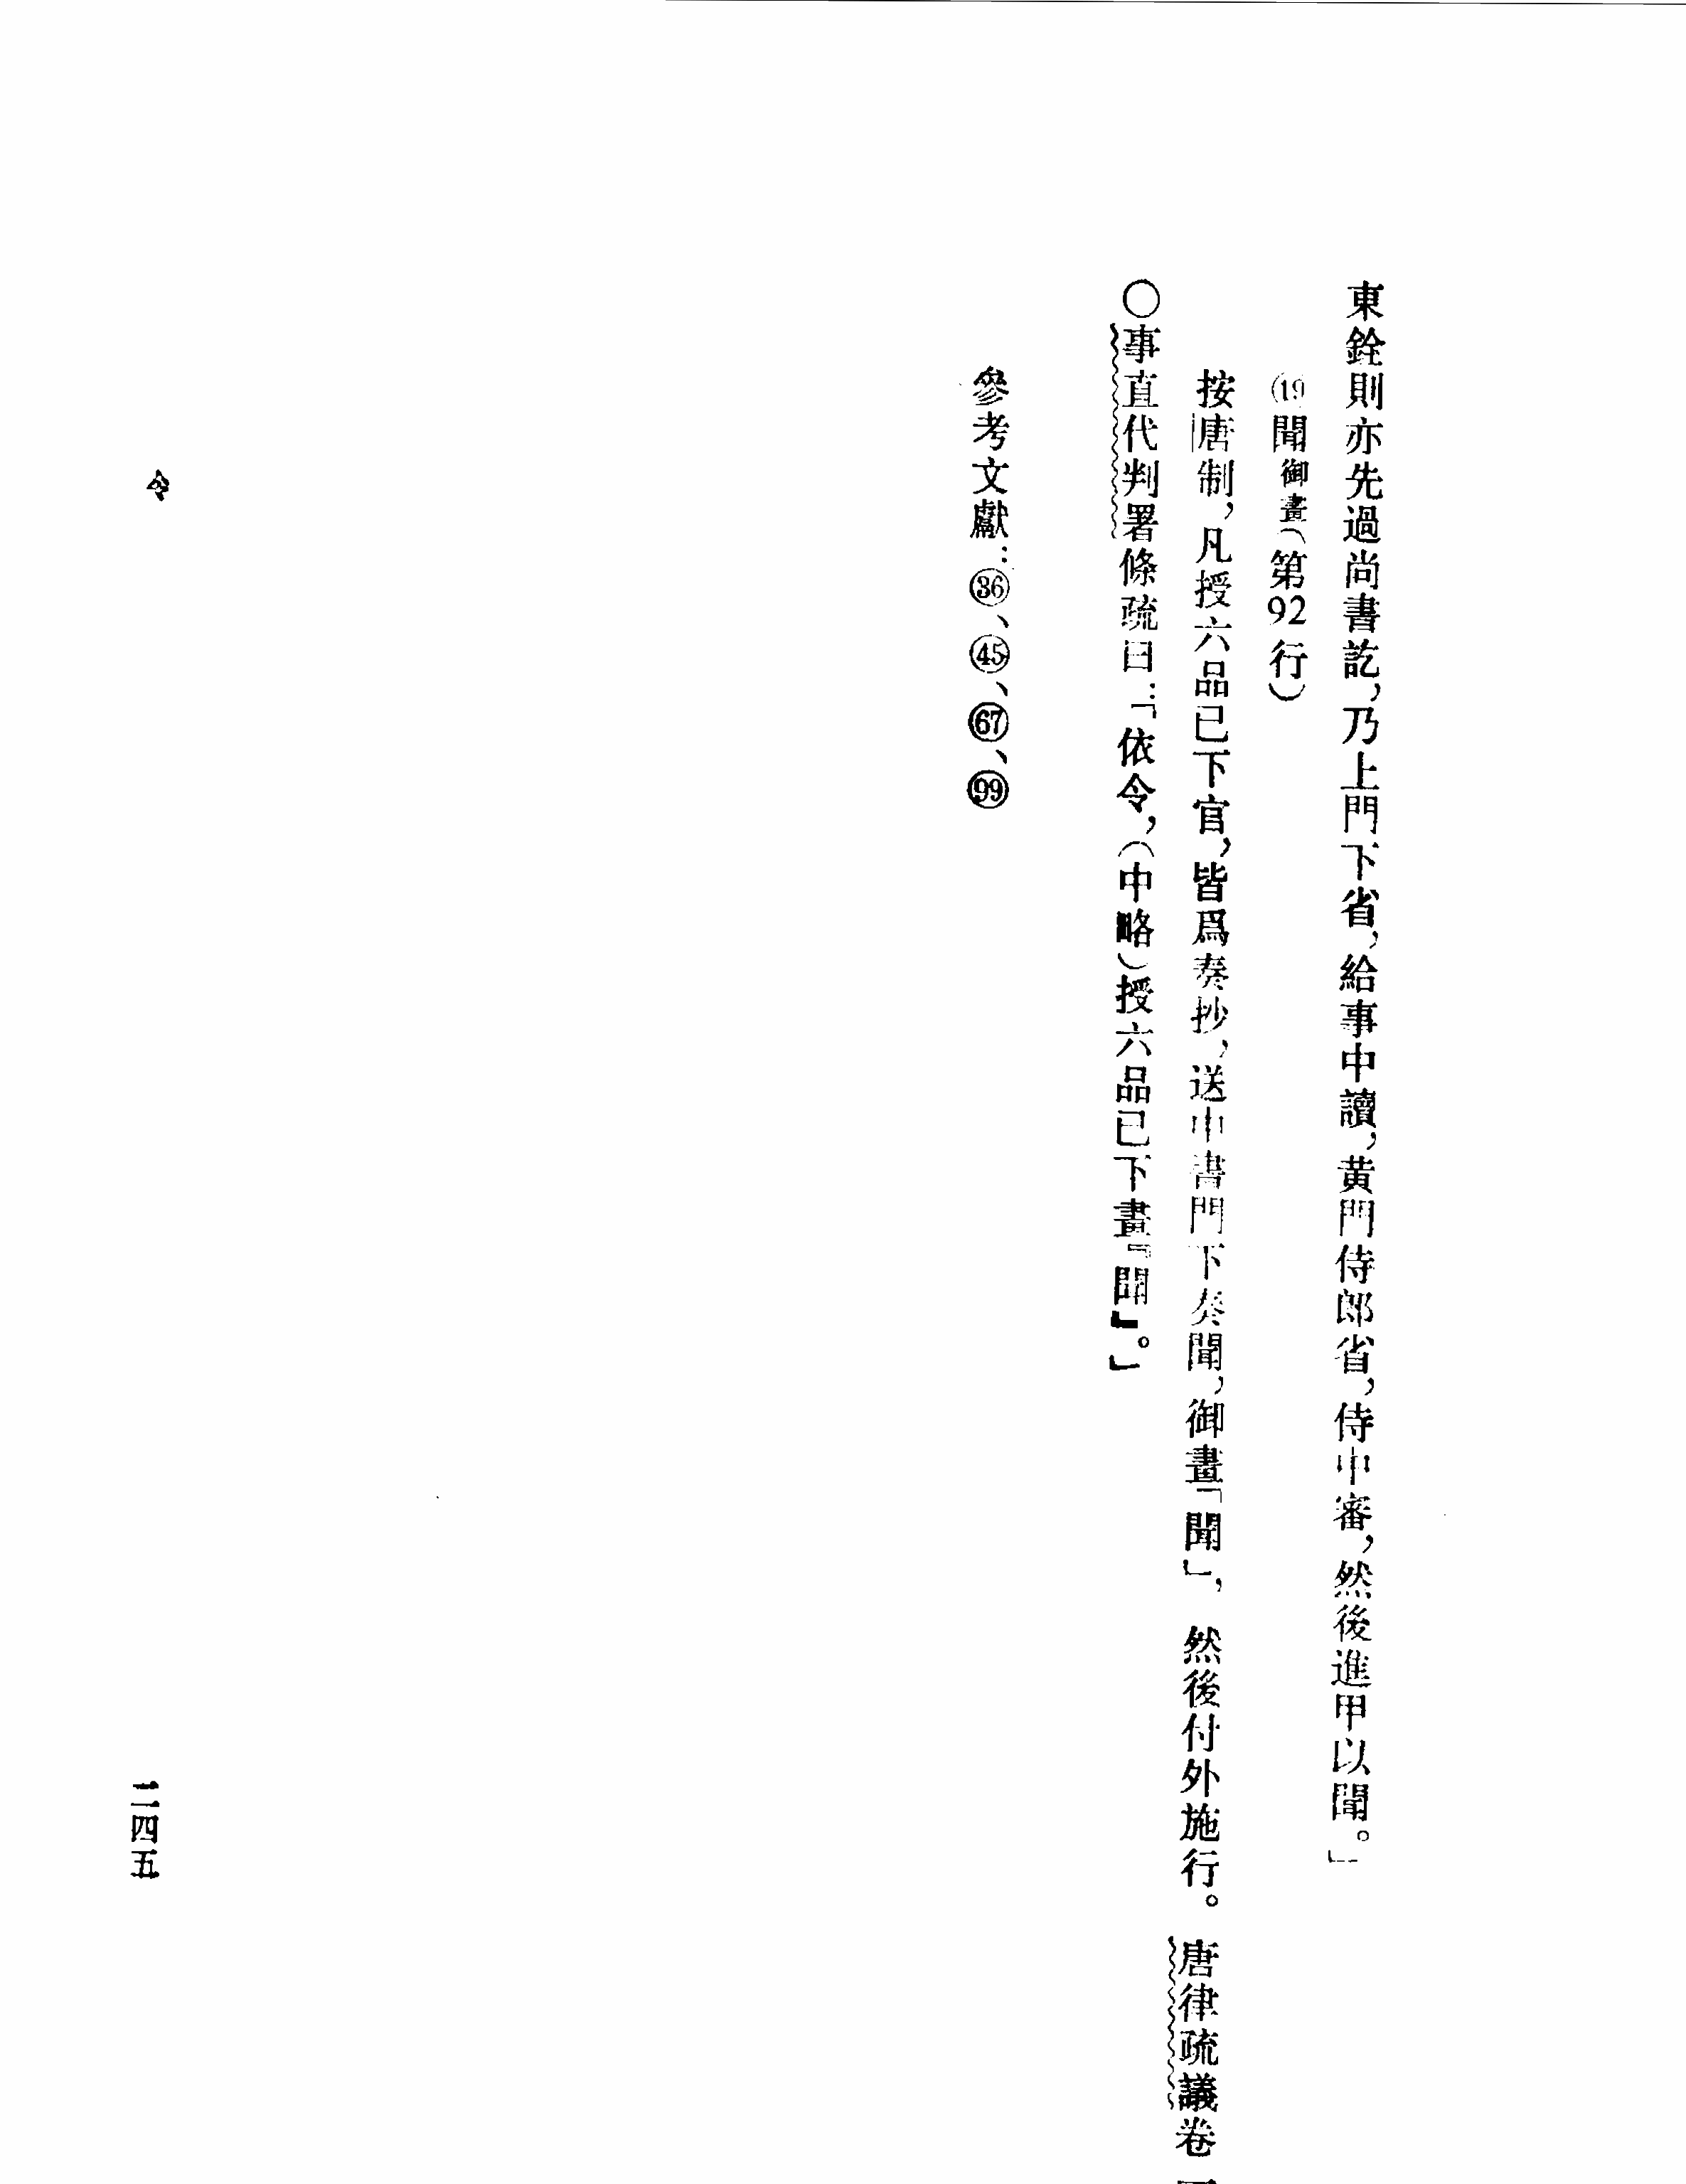


▶  Review each card above, then edit `human_prefs` in the next cell.
   Focus on the replace-opcode column — new algorithm: LLM wins these.
   Options: "paddleocr" | "qwen_vl_ocr" | "deepseek_ocr" | "agree"


In [5]:
# ── HITL calibration: 4-panel display (image + Paddle + Qwen + DeepSeek) ──────
import base64
import html as _html

from IPython.display import HTML, display

from apps.backend.ocr.base import OCRLine, OCRPageResult
from apps.backend.ocr.fusion import _noise_index, _cjk_ratio, fuse_results
from apps.backend.storage.minio_client import get_minio_client

HITL_N    = int(os.getenv('HITL_N', '15'))
SKIP_HITL = os.getenv('SKIP_HITL', '0') == '1'
BUCKET    = os.getenv('MINIO_BUCKET_PAGES', 'ancient-pages')

# Populated below, consumed by calibration cell.
_hitl_sample:  list[dict]     = []
_algo_choices: dict[str, str] = {}   # page_id → winner engine id


# ── Helpers: hydrate OCR results from Neo4j rows ──────────────────────────────
def _hydrate_lines_local(lines_json: str | None) -> list[OCRLine]:
    if not lines_json:
        return []
    try:
        payload = json.loads(lines_json)
    except json.JSONDecodeError:
        return []
    return [
        OCRLine(
            text=e.get('text') or '',
            confidence=float(e.get('confidence') or 0.0),
            bbox=tuple(e['bbox']) if e.get('bbox') and len(e['bbox']) == 4 else None,
            order=int(e.get('order') or 0),
        )
        for e in payload if isinstance(e, dict)
    ]


def _row_to_paddle_local(row: dict) -> OCRPageResult:
    return OCRPageResult(
        engine='paddleocr',
        model_version=row.get('paddle_model') or 'PP-OCRv5',
        page_id=row['page_id'],
        text=row.get('paddle_text') or '',
        lines=_hydrate_lines_local(row.get('paddle_lines_json')),
        confidence=float(row.get('paddle_confidence') or 0.0),
        char_count=len((row.get('paddle_text') or '').replace('\n', '').strip()),
        error=row.get('paddle_error') if row.get('paddle_status') != 'ok' else None,
    )


def _row_to_deepseek_local(row: dict) -> OCRPageResult:
    return OCRPageResult(
        engine='deepseek_ocr',
        model_version=row.get('deepseek_model') or 'deepseek-ocr',
        page_id=row['page_id'],
        text=row.get('deepseek_text') or '',
        lines=_hydrate_lines_local(row.get('deepseek_lines_json')),
        confidence=float(row.get('deepseek_confidence') or 0.0),
        char_count=len((row.get('deepseek_text') or '').replace('\n', '').strip()),
        error=row.get('deepseek_error') if row.get('deepseek_status') != 'ok' else None,
    )


def _row_to_qwen_local(row: dict) -> OCRPageResult | None:
    if not row.get('qwen_text') and row.get('qwen_status') != 'ok':
        return None
    return OCRPageResult(
        engine='qwen_vl_ocr',
        model_version=row.get('qwen_model') or 'qwen-vl-ocr-latest',
        page_id=row['page_id'],
        text=row.get('qwen_text') or '',
        lines=_hydrate_lines_local(row.get('qwen_lines_json')),
        confidence=float(row.get('qwen_confidence') or 0.0),
        char_count=len((row.get('qwen_text') or '').replace('\n', '').strip()),
        error=row.get('qwen_error') if row.get('qwen_status') != 'ok' else None,
    )


# ── MinIO client ──────────────────────────────────────────────────────────────
try:
    _minio = get_minio_client()
    _minio.list_buckets()
    _minio_ok = True
    print(f'MinIO connected  (bucket={BUCKET})')
except Exception as _minio_err:
    _minio    = None
    _minio_ok = False
    print(f'⚠ MinIO unavailable ({_minio_err}) — images omitted from display.')


def _fetch_image_b64(uri: str | None) -> str | None:
    if not uri or not _minio_ok:
        return None
    try:
        resp = _minio.get_object(BUCKET, uri)
        try:
            data = resp.read()
        finally:
            resp.close()
            resp.release_conn()
        return base64.b64encode(data).decode('ascii')
    except Exception:
        return None


# ── Quality badge helper ──────────────────────────────────────────────────────
def _quality_badge(text: str, paddle_chars: int) -> str:
    """Return a short HTML quality summary for an LLM output."""
    if not text:
        return '<span style="color:#888">no output</span>'
    n = len(text)
    ratio = n / max(paddle_chars, 1)
    cjk   = _cjk_ratio(text)
    noise = _noise_index(text)
    flags: list[str] = []
    if ratio > 3.0:
        flags.append(f'<b style="color:#b91c1c">3×len ({ratio:.1f}x)</b>')
    if cjk < 0.40:
        flags.append(f'<b style="color:#b91c1c">CJK={cjk:.2f}</b>')
    if noise > 0.30:
        flags.append(f'<b style="color:#b91c1c">noise={noise:.2f}</b>')
    if flags:
        verdict = '⛔ excluded: ' + ', '.join(flags)
    else:
        verdict = f'✓ gate pass  CJK={cjk:.2f} noise={noise:.2f} len×={ratio:.1f}'
    return verdict


# ── HTML renderer: 4-panel card per page ─────────────────────────────────────
_CARD_CSS = """
<style>
.hitl-card {
    border: 1px solid #d0d0d0; border-radius: 8px; margin: 18px 0;
    padding: 14px 16px; background: #fafafa; font-family: sans-serif;
}
.hitl-card h4 { margin: 0 0 4px 0; font-size: 14px; color: #222; }
.hitl-card .meta { font-size: 12px; color: #555; margin-bottom: 10px; }
.hitl-panels { display: flex; gap: 10px; align-items: flex-start; }
.hitl-panel { flex: 1; min-width: 0; }
.hitl-panel h5 {
    margin: 0 0 4px 0; font-size: 11px; font-weight: 600;
    text-transform: uppercase; letter-spacing: .04em; color: #444;
}
.hitl-panel img { width: 100%; border-radius: 4px; border: 1px solid #ccc; }
.hitl-panel .no-img {
    width: 100%; min-height: 140px; background: #eee; border-radius: 4px;
    display: flex; align-items: center; justify-content: center;
    font-size: 12px; color: #888;
}
.hitl-text {
    font-family: 'PingFang SC', 'Hiragino Sans GB', 'Noto Sans CJK SC',
                 'Source Han Sans', monospace;
    font-size: 12px; line-height: 1.6; white-space: pre-wrap;
    background: #fff; border: 1px solid #ddd; border-radius: 4px;
    padding: 6px 8px; max-height: 420px; overflow-y: auto;
    word-break: break-all;
}
.hitl-qual { font-size: 10px; margin: 3px 0 6px 0; }
.hitl-diffs { margin-top: 10px; font-size: 12px; color: #333; }
.hitl-diffs table { border-collapse: collapse; width: 100%; }
.hitl-diffs td, .hitl-diffs th {
    border: 1px solid #e0e0e0; padding: 3px 7px; text-align: left;
    font-family: 'PingFang SC', monospace; font-size: 11px;
}
.hitl-diffs th { background: #f0f0f0; font-weight: 600; }
.algo-badge {
    display: inline-block; padding: 2px 8px; border-radius: 10px;
    font-size: 11px; font-weight: 600;
}
.algo-paddle   { background: #dbeafe; color: #1d4ed8; }
.algo-qwen     { background: #f3e8ff; color: #6b21a8; }
.algo-deepseek { background: #dcfce7; color: #166534; }
</style>
"""

_ENGINE_LABEL = {
    'paddleocr':    ('PaddleOCR', 'algo-paddle'),
    'qwen_vl_ocr':  ('Qwen-VL-OCR', 'algo-qwen'),
    'deepseek_ocr': ('DeepSeek-OCR', 'algo-deepseek'),
}


def _build_hitl_html(sample: list[dict], algo_choices: dict[str, str],
                     n_low: int, n_mid: int) -> str:
    parts: list[str] = [_CARD_CSS]
    for i, item in enumerate(sample, start=1):
        row   = item['row']
        trial = item['trial']
        agr   = trial.agreement_rate
        band  = 'low' if i <= n_low else ('mid' if i <= n_low + n_mid else 'high')
        band_colour = {'low': '#fee2e2', 'mid': '#fef9c3', 'high': '#dcfce7'}[band]
        agr_label = (
            f'{agr:.3f} — {"low" if agr < 0.6 else ("medium" if agr < 0.9 else "high")} divergence'
            if agr is not None else 'N/A (single-engine)'
        )
        algo_id     = algo_choices.get(trial.page_id, 'qwen_vl_ocr')
        badge_lbl, badge_cls = _ENGINE_LABEL.get(algo_id, (algo_id, 'algo-paddle'))

        # Image panel
        img_b64  = _fetch_image_b64(row.get('preprocessed_uri'))
        img_html = (
            f'<img src="data:image/png;base64,{img_b64}" alt="page image"/>'
            if img_b64 else '<div class="no-img">image unavailable</div>'
        )

        # OCR text panels with quality gate summary
        p_text = _html.escape((row.get('paddle_text')  or '(no output)').strip())
        q_text = _html.escape((row.get('qwen_text')    or '(no output)').strip())
        d_text = _html.escape((row.get('deepseek_text')or '(no output)').strip())
        p_conf = float(row.get('paddle_confidence')  or 0.0)
        p_chars = trial.paddle_chars
        q_qual = _quality_badge(row.get('qwen_text') or '', p_chars)
        d_qual = _quality_badge(row.get('deepseek_text') or '', p_chars)

        # Disagreement table (replace opcodes)
        replace_segs  = [s for s in trial.segments if s.op == 'replace']
        ins_del_segs  = [s for s in trial.segments if s.op in ('insert', 'delete')]
        diff_html = ''
        if replace_segs or ins_del_segs:
            paddle_raw  = row.get('paddle_text') or ''
            llm_raw     = (row.get('qwen_text') or row.get('deepseek_text') or '')
            rows_html = ''.join(
                f'<tr>'
                f'<td>{_html.escape(paddle_raw[s.a_range[0]:s.a_range[1]])}</td>'
                f'<td>{_html.escape(llm_raw[s.b_range[0]:s.b_range[1]])}</td>'
                f'<td><b>{s.source}</b> &nbsp;'
                f'{"✓ LLM" if s.source != "paddleocr" else "← Paddle"}</td>'
                f'</tr>'
                for s in replace_segs[:8]
            )
            more = (
                f'<tr><td colspan="3">… +{len(replace_segs)-8} more</td></tr>'
                if len(replace_segs) > 8 else ''
            )
            diff_html = f"""
            <div class="hitl-diffs">
              <b>Disagreements</b>: {len(replace_segs)} replace &nbsp; {len(ins_del_segs)} insert/delete
              &nbsp; <i>(new algorithm: LLM wins replace — verify this is correct)</i>
              <table>
                <tr><th>Paddle span (anchor)</th><th>LLM span (correction)</th><th>Algorithm picks</th></tr>
                {rows_html}{more}
              </table>
            </div>"""

        parts.append(f"""
        <div class="hitl-card">
          <h4>[{i}/{len(sample)}] &nbsp; {_html.escape(trial.page_id)}</h4>
          <div class="meta">
            document: {_html.escape(row.get('document_id','?'))} &nbsp;|&nbsp;
            tier: {_html.escape(str(row.get('tier','?')))} &nbsp;|&nbsp;
            agreement: {agr_label}
            &nbsp;|&nbsp; band:
            <span style="background:{band_colour};padding:1px 6px;border-radius:4px">{band}</span>
            &nbsp;|&nbsp; winner LLM:
            <span class="algo-badge {badge_cls}">{badge_lbl}</span>
          </div>
          <div class="hitl-panels">
            <div class="hitl-panel">
              <h5>Preprocessed image</h5>
              {img_html}
            </div>
            <div class="hitl-panel">
              <h5>PaddleOCR — anchor &nbsp; conf={p_conf:.3f} &nbsp; {p_chars} chars</h5>
              <div class="hitl-text">{p_text}</div>
            </div>
            <div class="hitl-panel">
              <h5>Qwen-VL-OCR — primary LLM &nbsp; {trial.qwen_chars} chars</h5>
              <div class="hitl-qual">{q_qual}</div>
              <div class="hitl-text">{q_text}</div>
            </div>
            <div class="hitl-panel">
              <h5>DeepSeek-OCR — secondary &nbsp; {trial.deepseek_chars} chars</h5>
              <div class="hitl-qual">{d_qual}</div>
              <div class="hitl-text">{d_text}</div>
            </div>
          </div>
          {diff_html}
        </div>""")
    return '\n'.join(parts)


# ── Main HITL flow ────────────────────────────────────────────────────────────
if SKIP_HITL:
    print('SKIP_HITL=1 — skipping pre-fusion HITL calibration.')
else:
    with driver.session() as session:
        hitl_rows = list(session.run(
            '''
            MATCH (p:PAGE)
            WHERE p.mode = 'ocr'
              AND (p.role IS NULL OR p.role = 'body')
              AND p.paddleOcrStatus = 'ok'
              AND (p.qwenVlOcrStatus = 'ok' OR p.deepseekOcrStatus = 'ok')
            RETURN
              p.id                      AS page_id,
              p.documentId              AS document_id,
              p.tier                    AS tier,
              p.preprocessedImageUri    AS preprocessed_uri,
              p.paddleOcrStatus         AS paddle_status,
              p.paddleOcrText           AS paddle_text,
              p.paddleOcrLinesJson      AS paddle_lines_json,
              p.paddleOcrConfidence     AS paddle_confidence,
              p.paddleOcrModelVersion   AS paddle_model,
              p.paddleOcrError          AS paddle_error,
              p.qwenVlOcrStatus         AS qwen_status,
              p.qwenVlOcrText           AS qwen_text,
              p.qwenVlOcrLinesJson      AS qwen_lines_json,
              p.qwenVlOcrConfidence     AS qwen_confidence,
              p.qwenVlOcrModelVersion   AS qwen_model,
              p.qwenVlOcrError          AS qwen_error,
              p.deepseekOcrStatus       AS deepseek_status,
              p.deepseekOcrText         AS deepseek_text,
              p.deepseekOcrLinesJson    AS deepseek_lines_json,
              p.deepseekOcrConfidence   AS deepseek_confidence,
              p.deepseekOcrModelVersion AS deepseek_model,
              p.deepseekOcrError        AS deepseek_error
            ORDER BY p.documentId, p.docPageIndex
            LIMIT $limit
            ''',
            limit=HITL_N * 4,
        ))

    if not hitl_rows:
        print(
            '⚠  No pages found with Paddle + at least one LLM engine completed.\n'
            '   Make sure 03_dual_extraction.ipynb and scripts/run_qwen_ocr.py have run.\n'
            '   Or set SKIP_HITL=1 to bypass.'
        )
        SKIP_HITL = True
    else:
        # Compute trial fusions in-memory — NO writes to Neo4j.
        candidates: list[dict] = []
        for raw in hitl_rows:
            row          = dict(raw)
            paddle_res   = _row_to_paddle_local(row)
            deepseek_res = _row_to_deepseek_local(row)
            qwen_res     = _row_to_qwen_local(row)
            trial        = fuse_results(paddle_res, deepseek_res, qwen_res)
            candidates.append({
                'row': row, 'paddle': paddle_res,
                'deepseek': deepseek_res, 'qwen': qwen_res, 'trial': trial,
            })

        # Stratify into terciles by ascending agreement rate.
        candidates.sort(
            key=lambda x: x['trial'].agreement_rate
            if x['trial'].agreement_rate is not None else 1.0
        )
        n    = min(HITL_N, len(candidates))
        n3   = max(n // 3, 1)
        low  = candidates[:n3]
        mid  = candidates[n3: 2 * n3]
        high = candidates[2 * n3: 2 * n3 + max(n - 2 * n3, 0)]
        _hitl_sample = low + mid + high

        # Pre-seed algo choices: winner_llm from trial (Qwen > DeepSeek by priority),
        # fallback to paddleocr when single_engine.
        for item in _hitl_sample:
            trial = item['trial']
            if trial.single_engine:
                _algo_choices[trial.page_id] = trial.single_engine
            elif trial.winner_llm:
                _algo_choices[trial.page_id] = trial.winner_llm
            else:
                _algo_choices[trial.page_id] = 'paddleocr'

        print(f'Pages available (Paddle + ≥1 LLM): {len(hitl_rows)}')
        print(f'Sample size                        : {len(_hitl_sample)}  '
              f'({len(low)} low / {len(mid)} mid / {len(high)} high agreement)')
        print('Rendering 4-panel display …')
        display(HTML(
            _build_hitl_html(_hitl_sample, _algo_choices, len(low), len(mid))
        ))
        print()
        print('▶  Review each card above, then edit `human_prefs` in the next cell.')
        print('   Focus on the replace-opcode column — new algorithm: LLM wins these.')
        print('   Options: "paddleocr" | "qwen_vl_ocr" | "deepseek_ocr" | "agree"')


In [6]:
# ── Human preference annotations ─────────────────────────────────────────────
# Review the 4-panel cards above, then set your preference for each page.
#
# Valid values:
#   "agree"        — accept the algorithm's choice (Qwen by default for LLM pages)
#   "qwen_vl_ocr"  — you prefer Qwen-VL's transcription for this page
#   "paddleocr"    — you prefer PaddleOCR's transcription (override LLM-wins rule)
#   "deepseek_ocr" — you prefer DeepSeek's transcription (only when Qwen was excluded)
#
# Key things to look for in the replace-opcode column:
#   - Does the LLM correctly recover a rare 古文 glyph Paddle mis-read? → "agree"
#   - Does the LLM introduce noise / hallucination that the quality gate missed? → "paddleocr"
#   - Is Qwen excluded (quality gate) and DeepSeek's output actually worse than Paddle? → "paddleocr"
#
# The dict is pre-seeded with "agree" for every page.
# After editing, run the calibration report cell immediately below.

human_prefs: dict[str, str] = {
    page_id: 'agree'
    for page_id in _algo_choices
}

# ← Edit values here as needed. Examples:
#   'some_doc__abc123::p00042': 'paddleocr',
#   'some_doc__abc123::p00107': 'qwen_vl_ocr',

human_satisfied: bool = False  # ← flip to True once you are confident
                                #   in the fusion algorithm's behaviour

print(f'human_prefs: {len(human_prefs)} pages loaded.')
if human_prefs:
    print('Edit values above, then run the calibration cell below.')
    print('Set human_satisfied = True when ready to proceed to corpus fusion.')


human_prefs: 15 pages loaded.
Edit values above, then run the calibration cell below.
Set human_satisfied = True when ready to proceed to corpus fusion.


In [7]:
# ── Calibration report + proceed gate ────────────────────────────────────────
if SKIP_HITL:
    print('SKIP_HITL=1 — calibration skipped, proceeding to corpus fusion.')
elif not _hitl_sample:
    print('No HITL sample available. Continuing.')
else:
    _valid = {'paddleocr', 'qwen_vl_ocr', 'deepseek_ocr', 'agree'}
    _bad   = {k: v for k, v in human_prefs.items() if v not in _valid}
    if _bad:
        raise ValueError(
            f'Invalid human_prefs values '
            f'(must be paddleocr | qwen_vl_ocr | deepseek_ocr | agree): {_bad}'
        )

    _agreements:    int        = 0
    _overrides:     list[dict] = []
    _pref_counts:   dict[str, int] = {'paddleocr': 0, 'qwen_vl_ocr': 0, 'deepseek_ocr': 0}
    _llm_wins_ok:   int        = 0   # replace opcodes where human agrees LLM should win
    _llm_wins_bad:  int        = 0   # replace opcodes where human prefers Paddle

    for _page_id, _human in human_prefs.items():
        _algo      = _algo_choices.get(_page_id, 'qwen_vl_ocr')
        _effective = _algo if _human == 'agree' else _human
        if _human == 'agree' or _human == _algo:
            _agreements += 1
        else:
            _item = next((x for x in _hitl_sample if x['trial'].page_id == _page_id), None)
            _agr  = _item['trial'].agreement_rate if _item else None
            _overrides.append({
                'page_id':   _page_id,
                'algo':      _algo,
                'human':     _human,
                'agreement': _agr,
            })
        _pref_counts[_effective] = _pref_counts.get(_effective, 0) + 1
        # Track LLM-wins-replace sentiment
        if _effective in ('qwen_vl_ocr', 'deepseek_ocr'):
            _llm_wins_ok  += 1
        else:
            _llm_wins_bad += 1

    _total   = len(human_prefs)
    _pct_agr = (_agreements / _total * 100) if _total else 0.0
    _sep     = '─' * 62

    print(_sep)
    print('  HITL Calibration Report — quality-signal-gated fusion')
    print(_sep)
    print(f'  Pages reviewed          : {_total}')
    print(f'  Agreed with algorithm   : {_agreements}/{_total}  ({_pct_agr:.0f}%)')
    print(f'  Overrode algorithm      : {len(_overrides)}/{_total}')
    print()
    print(f'  Effective preference breakdown:')
    for _eng, _cnt in sorted(_pref_counts.items(), key=lambda x: -x[1]):
        _pct = _cnt / _total * 100 if _total else 0.0
        print(f'    {_eng:<18} {_cnt:3d} pages  ({_pct:.0f}%)')
    print()
    _llm_total = _llm_wins_ok + _llm_wins_bad
    if _llm_total:
        print(f'  LLM wins replace opcodes: human agrees on '
              f'{_llm_wins_ok}/{_llm_total} ({_llm_wins_ok/_llm_total*100:.0f}%) pages')
        if _llm_wins_ok / _llm_total < 0.50:
            print('  ⚠  Human prefers Paddle on >50 % of pages — consider revisiting the')
            print('     replace-opcode policy in fusion.py (plan §6 Stage 3d).')
        else:
            print('  ✓  Human agrees LLM should win replace opcodes on most pages.')
    print()

    if _overrides:
        print(f'  Pages where you overrode the algorithm ({len(_overrides)}):')
        for _d in _overrides:
            _agr_str = f'{_d["agreement"]:.3f}' if _d['agreement'] is not None else 'N/A'
            print(f'    {_d["page_id"]}')
            print(f'      algo={_d["algo"]}  human={_d["human"]}  agreement={_agr_str}')
        print()

    if _pct_agr >= 60:
        print(f'  ✓ {_pct_agr:.0f}% agreement with algorithm — well-calibrated.')
    else:
        print(
            f'  ⚠ {_pct_agr:.0f}% agreement — consider reviewing quality-gate thresholds\n'
            f'    (char_ratio_limit / cjk_ratio_min / noise_index_max) in fusion.py\n'
            f'    or the replace-opcode policy before the full corpus run.'
        )
    print(_sep)

    # Persist calibration log.
    _cal_path    = ARTIFACT_DIR / 'hitl_calibration.json'
    _cal_payload = {
        'generated_at':     datetime.now(timezone.utc).isoformat(),
        'fusion_algorithm': 'quality-signal-gated v2 (LLM wins replace, Qwen priority)',
        'hitl_n':           HITL_N,
        'pages_reviewed':   _total,
        'agreement_rate':   round(_pct_agr / 100, 4),
        'agreements':       _agreements,
        'overrides':        _overrides,
        'pref_counts':      _pref_counts,
        'llm_wins_replace_ok':  _llm_wins_ok,
        'llm_wins_replace_bad': _llm_wins_bad,
        'human_prefs':  human_prefs,
        'algo_choices': _algo_choices,
    }
    _cal_path.write_text(json.dumps(_cal_payload, ensure_ascii=False, indent=2))
    print(f'\n  Calibration log saved → {_cal_path}')

    assert human_satisfied, (
        '\n'
        '  ┌─ HITL gate: not yet satisfied ─────────────────────────────┐\n'
        '  │  Review the 4-panel output and calibration report above.   │\n'
        '  │  When you are confident in the fusion algorithm, flip      │\n'
        '  │      human_satisfied = True                                │\n'
        '  │  in the cell above and re-run this cell.                   │\n'
        '  │  To bypass entirely: set env var SKIP_HITL=1               │\n'
        '  └────────────────────────────────────────────────────────────┘\n'
    )
    print('\n  human_satisfied = True — proceeding to corpus fusion run.')


──────────────────────────────────────────────────────────────
  HITL Calibration Report — quality-signal-gated fusion
──────────────────────────────────────────────────────────────
  Pages reviewed          : 15
  Agreed with algorithm   : 15/15  (100%)
  Overrode algorithm      : 0/15

  Effective preference breakdown:
    qwen_vl_ocr         15 pages  (100%)
    paddleocr            0 pages  (0%)
    deepseek_ocr         0 pages  (0%)

  LLM wins replace opcodes: human agrees on 15/15 (100%) pages
  ✓  Human agrees LLM should win replace opcodes on most pages.

  ✓ 100% agreement with algorithm — well-calibrated.
──────────────────────────────────────────────────────────────

  Calibration log saved → /Users/mohasani/Ancient/notebooks/_artifacts/03b_fusion/hitl_calibration.json


AssertionError: 
  ┌─ HITL gate: not yet satisfied ─────────────────────────────┐
  │  Review the 4-panel output and calibration report above.   │
  │  When you are confident in the fusion algorithm, flip      │
  │      human_satisfied = True                                │
  │  in the cell above and re-run this cell.                   │
  │  To bypass entirely: set env var SKIP_HITL=1               │
  └────────────────────────────────────────────────────────────┘


## 3. Qwen-VL-OCR run + quality-signal-gated 3-engine corpus fusion + language re-detection

**Step 3a** — Run Qwen-VL-OCR on pages that have not been processed yet.
Skip with `SKIP_QWEN_RUN=1` if `scripts/run_qwen_ocr.py` already ran in the background.

**Step 3b** — Fuse all 3 engines using the updated quality-signal gate:
- LLMs with `char_count > 3× paddle`, `cjk_ratio < 0.40`, or `noise_index > 0.30` are excluded.
- Qwen wins by default; DeepSeek is the fallback secondary.
- LLM wins `replace` opcodes (character correction); Paddle anchors structure.
- Pages where all LLMs fail the gate fall back to Paddle only.

Set `RUN_FULL=1` for the full corpus (default: `MAX_PAGES=30` smoke run).

In [ ]:
import os
from apps.backend.pipeline.extract import run_qwen_pages
from apps.backend.pipeline.fusion import fuse_pages, fusion_summary
from apps.backend.llm.silra import get_silra_client
from apps.backend.storage.minio_client import get_minio_client

SKIP_QWEN_RUN = os.getenv('SKIP_QWEN_RUN', '0') == '1'

# ── Step 3a: Qwen-VL-OCR ──────────────────────────────────────────────────
if not SKIP_QWEN_RUN:
    print('Running Qwen-VL-OCR...')
    minio = get_minio_client()
    silra = get_silra_client(timeout=180.0)
    qwen_report = run_qwen_pages(
        driver=driver,
        minio_client=minio,
        silra_client=silra,
        document_id=DOCUMENT_ID,
        max_pages=MAX_PAGES,
        recompute_existing=RECOMPUTE,
        progress_every=10,
    )
    print(f'Qwen-VL-OCR: {qwen_report.pages_total} pages | '
          f'ok={qwen_report.pages_processed} '
          f'empty={qwen_report.pages_empty} '
          f'failed={qwen_report.pages_failed} '
          f'avg={qwen_report.avg_seconds_per_page:.1f}s/page')
else:
    print('SKIP_QWEN_RUN=1 — skipping Qwen-VL-OCR (already ran via background script)')

# ── Step 3b: 3-engine fusion ──────────────────────────────────────────────
print()
print('Running 3-engine fusion (Paddle × DeepSeek × Qwen-VL)...')
fuse_report = fuse_pages(
    driver,
    document_id=DOCUMENT_ID,
    max_pages=MAX_PAGES,
    recompute_existing=RECOMPUTE,
    run_language_detection=RUN_LANG_DETECT,
    progress_every=25,
)

print('Fusion run report:')
print(json.dumps(
    {k: v for k, v in fuse_report.to_dict().items()
     if k not in ('sample_outcomes', 'by_document')},
    indent=2, ensure_ascii=False,
))


In [ ]:
print('Sample fused outcomes:')
for o in fuse_report.sample_outcomes[:5]:
    print(f'  - {o["page_id"]}: status={o["status"]} '
          f'agreement={o["agreement_rate"]} '
          f'winner_llm={o["winner_llm"]} '
          f'paddle={o["paddle_chars"]} deepseek={o["deepseek_chars"]} '
          f'qwen={o["qwen_chars"]} fused={o["fused_chars"]} '
          f'lang={o["language"]}')

if fuse_report.sample_outcomes:
    first_id = fuse_report.sample_outcomes[0]['page_id']
    with driver.session() as session:
        row = session.run(
            '''
            MATCH (p:PAGE {id: $id})
            RETURN p.paddleOcrText AS paddle,
                   p.deepseekOcrText AS deepseek,
                   p.qwenVlOcrText AS qwen,
                   p.textFused AS fused,
                   p.fusionWinnerLlm AS winner_llm,
                   p.fusionAgreementRate AS agreement
            ''',
            id=first_id,
        ).single()
    if row:
        print()
        print(f'--- First sample page: {first_id} ---')
        print(f'Winner LLM : {row["winner_llm"]}')
        print(f'Agreement  : {row["agreement"]}')
        print('Paddle   :', (row['paddle'] or '')[:120])
        print('DeepSeek :', (row['deepseek'] or '')[:120])
        print('Qwen-VL  :', (row['qwen'] or '')[:120])
        print('Fused    :', (row['fused'] or '')[:120])


In [ ]:
from apps.backend.pipeline.extract import extraction_summary

fusion_sum = fusion_summary(driver)
print('Corpus-wide fusion summary:')
print(json.dumps(fusion_sum, indent=2, ensure_ascii=False))

# ── 3-engine benchmark ────────────────────────────────────────────────────
print()
print('=== 3-engine OCR status ===')
ext_sum = extraction_summary(driver)
total = ext_sum['total_ocr_pages']
print(f'Total body OCR pages: {total}')
print()
for engine, stats in ext_sum['by_engine_status'].items():
    ok      = stats.get('ok', 0)
    empty   = stats.get('empty', 0)
    failed  = stats.get('failed', 0)
    unset   = stats.get('(unset)', 0)
    ok_pct  = ok / total * 100 if total else 0
    bad_pct = (empty + failed) / total * 100 if total else 0
    print(f'  {engine:<18} ok={ok:4d} ({ok_pct:5.1f}%)  '
          f'empty+failed={empty+failed:4d} ({bad_pct:5.1f}%)  '
          f'pending={unset:4d}')

# ── Quality-gate hit rate ─────────────────────────────────────────────────
print()
print('=== Quality-gate analysis (quality-signal-gated fusion) ===')
with driver.session() as s:
    qg = s.run("""
        MATCH (p:PAGE) WHERE p.mode = 'ocr' AND (p.role IS NULL OR p.role = 'body')
          AND p.fusionStatus IS NOT NULL
        RETURN
          p.fusionSingleEngine AS single_engine,
          p.fusionWinnerLlm    AS winner_llm,
          p.fusionStatus       AS status,
          count(p)             AS n
        ORDER BY n DESC
    """).data()
print(f'  {"single_engine":<20} {"winner_llm":<18} {"status":<12} n')
print('  ' + '─' * 60)
for r in qg:
    print(f'  {str(r["single_engine"] or ""):<20} '
          f'{str(r["winner_llm"] or ""):<18} '
          f'{str(r["status"] or ""):<12} {r["n"]}')

# ── Agreement-rate distribution ───────────────────────────────────────────
print()
print('=== Agreement-rate distribution (LLM-wins-replace effect) ===')
with driver.session() as s:
    agr_rows = s.run("""
        MATCH (p:PAGE)
        WHERE p.mode = 'ocr' AND (p.role IS NULL OR p.role = 'body')
          AND p.fusionAgreementRate IS NOT NULL
        RETURN
          CASE
            WHEN p.fusionAgreementRate < 0.50 THEN '< 0.50 (high divergence)'
            WHEN p.fusionAgreementRate < 0.70 THEN '0.50–0.70'
            WHEN p.fusionAgreementRate < 0.90 THEN '0.70–0.90'
            ELSE '≥ 0.90 (high agreement)'
          END AS band,
          count(p) AS n
        ORDER BY band
    """).data()
for r in agr_rows:
    print(f'  {r["band"]:<35} {r["n"]:4d} pages')


In [ ]:
artifact = {
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'config': {
        'run_full': RUN_FULL,
        'max_pages': MAX_PAGES,
        'recompute': RECOMPUTE,
        'document_id': DOCUMENT_ID,
        'run_language_detection': RUN_LANG_DETECT,
    },
    'eligible': dict(eligible),
    'fuse_report': fuse_report.to_dict(),
    'fusion_summary': fusion_sum,
}
out_path = ARTIFACT_DIR / 'fusion.json'
out_path.write_text(json.dumps(artifact, ensure_ascii=False, indent=2))
print(f'Wrote {out_path} ({out_path.stat().st_size:,} bytes)')

## Next steps

Once fusion has run over the full corpus (`RUN_FULL=1`), move on to:

- **Phase 4 — `04_ocr_evaluation.ipynb`**: error analysis on a 100-page
  validation slice (CER / WER per engine + per-script), confidence
  calibration, and the first `EvalSuite` entries (plan §6 Stage 4).
- Inspect low-agreement pages via:

  ```cypher
  MATCH (p:PAGE)
  WHERE p.fusionAgreementRate IS NOT NULL
    AND p.fusionAgreementRate < 0.7
  RETURN p.id, p.fusionAgreementRate, substring(p.textFused, 0, 300)
  ORDER BY p.fusionAgreementRate ASC
  LIMIT 20
  ```